In [171]:
!pip install -q lightgbm gradio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib

In [172]:
np.random.seed(42)

In [173]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/48c74e3c-91ff-4dda-ba7e-0939da12cf70.xls')

In [175]:
print(df.shape)
print()

(478, 22)



In [176]:
print(df.duplicated().sum())

0


In [177]:
df.dtypes

,0
brand,object
model,object
top_speed_kmh,int64
battery_capacity_kWh,float64
battery_type,object
number_of_cells,float64
torque_nm,float64
efficiency_wh_per_km,int64
range_km,int64
acceleration_0_100_s,float64


In [178]:
print(df.isnull().sum().sort_values(ascending = False))
print()
print(df['cargo_volume_l'].unique()[:20])

number_of_cells              202
towing_capacity_kg            26
torque_nm                      7
fast_charging_power_kw_dc      1
fast_charge_port               1
model                          1
cargo_volume_l                 1
battery_capacity_kWh           0
top_speed_kmh                  0
brand                          0
battery_type                   0
acceleration_0_100_s           0
efficiency_wh_per_km           0
range_km                       0
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64

[185 360 496 472 400 326 502 520 535 526 511 '10 Banana Boxes' 514 350 405
 470 490 570 500 525]


In [179]:
banana_rows = df[df['cargo_volume_l'].astype(str).str.contains('Banana', case=False, na=False)]
print(banana_rows[['brand', 'model', 'cargo_volume_l']])

             brand               model   cargo_volume_l
29            Audi   Q6 e-tron quattro  10 Banana Boxes
213          Maxus              MIFA 9  31 Banana Boxes
246  Mercedes-Benz  EQS SUV 580 4MATIC  13 Banana Boxes


In [180]:
import re

def clean_cargo(val):
    if isinstance(val, str) and 'banana' in val.lower():
        num_boxes = int(re.findall(r'\d+', val)[0])
        # 1 banana box ≈ 30 liters (commonly cited informal reference unit)
        return num_boxes * 30
    return val

df['cargo_volume_l'] = df['cargo_volume_l'].apply(clean_cargo)
df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors='coerce')

In [181]:
df['torque_nm'] = df.groupby('segment')['torque_nm'].transform(lambda x: x.fillna(x.median()))

In [182]:
print(df['torque_nm'].isnull().sum())

0


In [183]:
print(df['towing_capacity_kg'].describe())
print(df['towing_capacity_kg'].value_counts().head(20))

count     452.000000
mean     1052.261062
std       737.851774
min         0.000000
25%       500.000000
50%      1000.000000
75%      1600.000000
max      2500.000000
Name: towing_capacity_kg, dtype: float64
towing_capacity_kg
0.0       106
750.0      51
1000.0     50
1500.0     46
1600.0     38
2000.0     32
1200.0     28
1800.0     23
500.0      14
1700.0     10
2100.0      8
2500.0      8
2250.0      7
1400.0      6
2400.0      4
2200.0      4
900.0       3
1300.0      2
1100.0      2
300.0       2
Name: count, dtype: int64


In [184]:
df['towing_capacity_kg'] = df.groupby('segment')['towing_capacity_kg'].transform(lambda x: x.fillna(x.median()))

In [185]:
print(df['towing_capacity_kg'].isnull().sum())

5


In [186]:
still_missing = df[df['towing_capacity_kg'].isnull()]
print(still_missing[['brand', 'model', 'segment']])

           brand                  model     segment
148      Hyundai      INSTER Long Range   JA - Mini
149      Hyundai  INSTER Standard Range   JA - Mini
198           MG           Cyberster GT  G - Sports
199           MG       Cyberster Trophy  G - Sports
364  Rolls-Royce                Spectre  I - Luxury


In [187]:
df['towing_capacity_kg'] = df['towing_capacity_kg'].fillna(df['towing_capacity_kg'].median())

In [188]:
df = df.drop(columns=['number_of_cells'])

In [189]:
df['model'] = df['model'].fillna('Unknown')

In [190]:
df['cargo_volume_l'] = df.groupby('segment')['cargo_volume_l'].transform(lambda x: x.fillna(x.median()))

In [191]:
df['fast_charging_power_kw_dc'] = df.groupby('segment')['fast_charging_power_kw_dc'].transform(lambda x: x.fillna(x.median()))

In [192]:
df['fast_charge_port'] = df['fast_charge_port'].fillna(df['fast_charge_port'].mode()[0])

In [193]:
print(df.isnull().sum().sort_values(ascending=False))

brand                        0
model                        0
top_speed_kmh                0
battery_capacity_kWh         0
battery_type                 0
torque_nm                    0
efficiency_wh_per_km         0
range_km                     0
acceleration_0_100_s         0
fast_charging_power_kw_dc    0
fast_charge_port             0
towing_capacity_kg           0
cargo_volume_l               0
seats                        0
drivetrain                   0
segment                      0
length_mm                    0
width_mm                     0
height_mm                    0
car_body_type                0
source_url                   0
dtype: int64


In [194]:
df = df.drop(columns=['battery_type', 'source_url'])


In [195]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Shape: (478, 19)


In [196]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/ev_cleaned.csv', index=False)

In [197]:
X = df.select_dtypes(include="number").drop(columns=["range_km"], errors="ignore")
y = df["range_km"]

## 2. Exploratory Data Analysis
Building on the cleaned dataset from Section 1.

In [198]:
sns.set_style("whitegrid")
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ev_cleaned.csv")

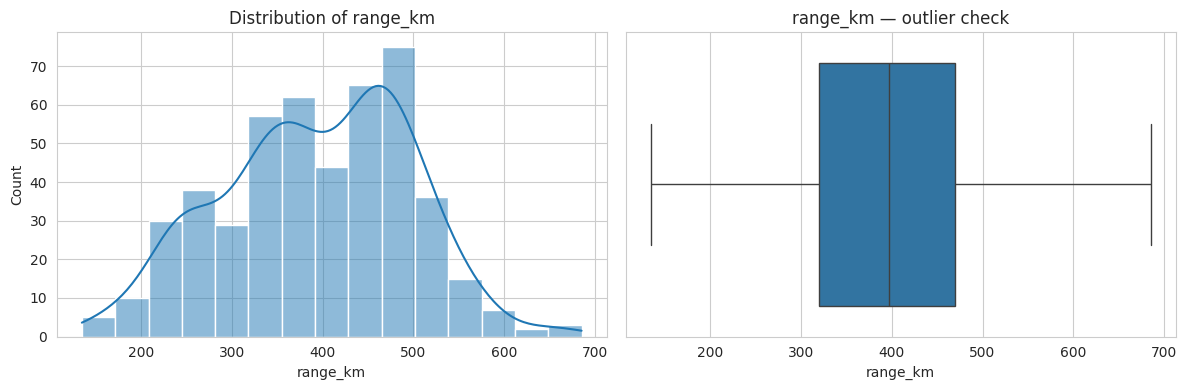

,range_km
count,478.000000
mean,393.179916
std,103.287335
min,135.000000
25%,320.000000
50%,397.500000
75%,470.000000
max,685.000000


In [199]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["range_km"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of range_km")
sns.boxplot(x=df["range_km"], ax=axes[1])
axes[1].set_title("range_km — outlier check")
plt.tight_layout()
plt.show()

df["range_km"].describe()

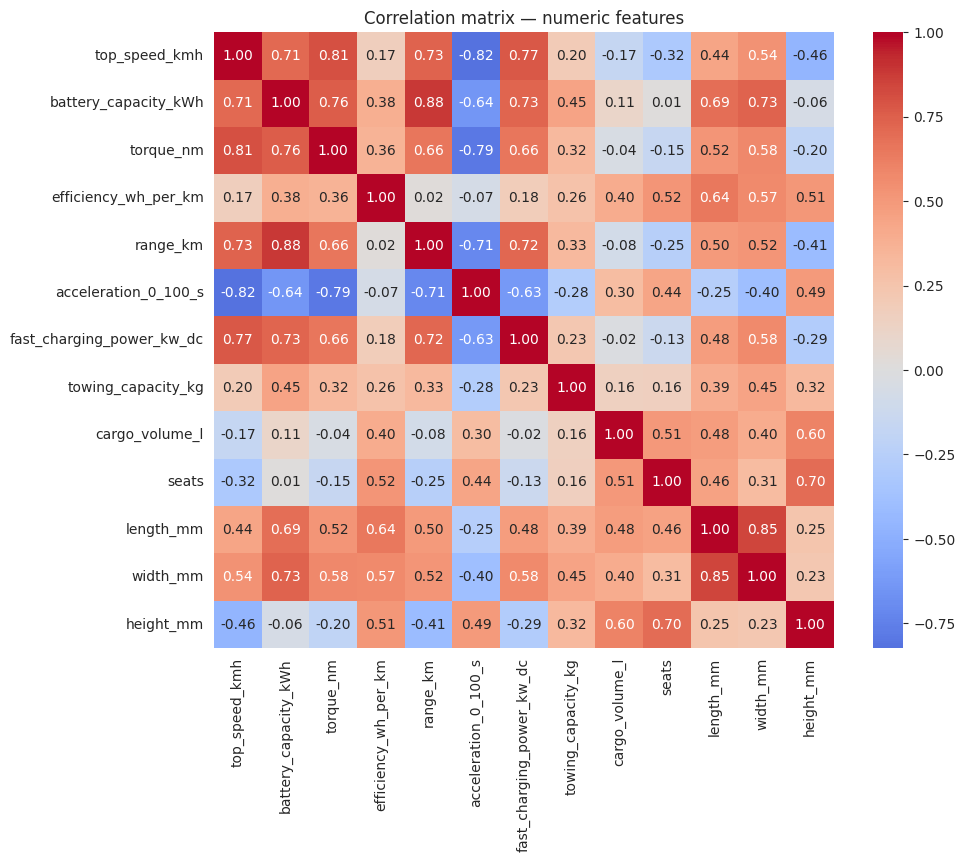

,range_km
range_km,1.000000
battery_capacity_kWh,0.880433
top_speed_kmh,0.732130
fast_charging_power_kw_dc,0.721623
torque_nm,0.658782
width_mm,0.521392
length_mm,0.496867
towing_capacity_kg,0.329623
efficiency_wh_per_km,0.022943
cargo_volume_l,-0.078923


In [200]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.show()

corr["range_km"].sort_values(ascending=False)

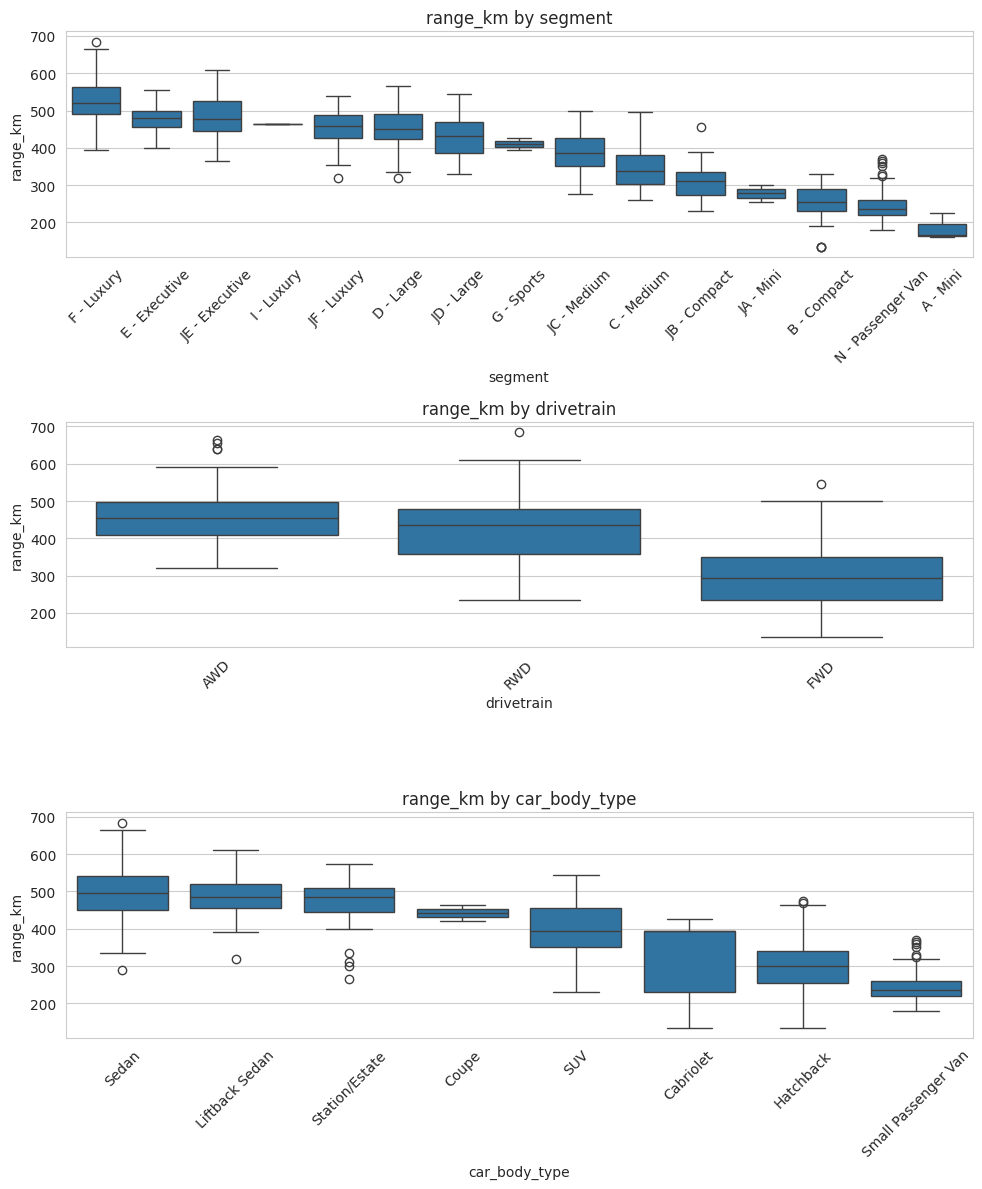

In [201]:
cat_cols = ["segment", "drivetrain", "car_body_type"]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4*len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)["range_km"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="range_km", order=order, ax=ax)
    ax.set_title(f"range_km by {col}")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

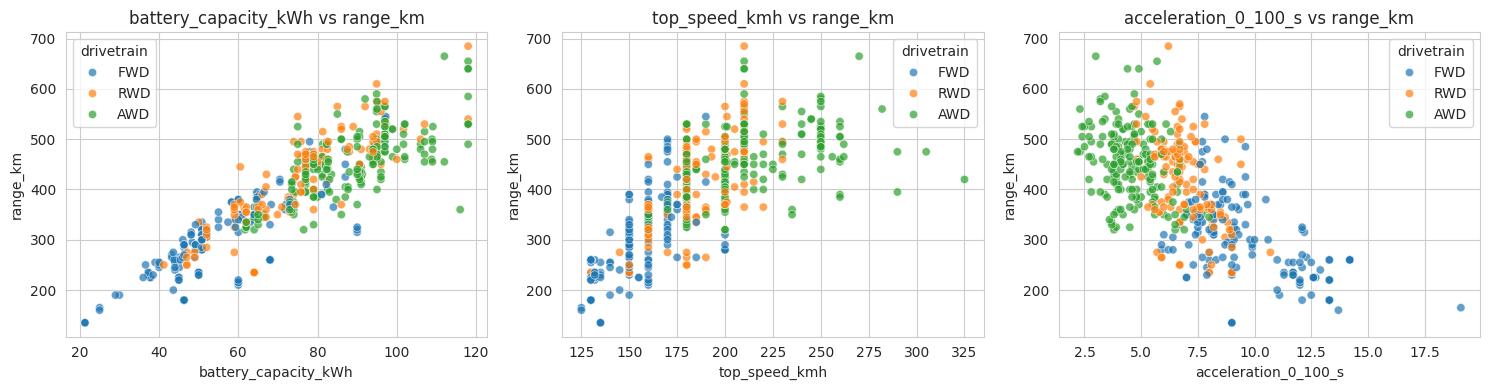

In [202]:
scatter_cols = ["battery_capacity_kWh", "top_speed_kmh", "acceleration_0_100_s"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, scatter_cols):
    sns.scatterplot(data=df, x=col, y="range_km", hue="drivetrain", ax=ax, alpha=0.7)
    ax.set_title(f"{col} vs range_km")
plt.tight_layout()
plt.show()

# MODELS

# 1 . RIDGE REGRESSION


In [203]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)
print(pipe.score(X_test, y_test))

0.9427370411947842


In [204]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipe = Pipeline([("prep", preprocessor), ("ridge", Ridge(alpha=1.0))])

In [205]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 19.86
RMSE: 24.62
R²: 0.9427


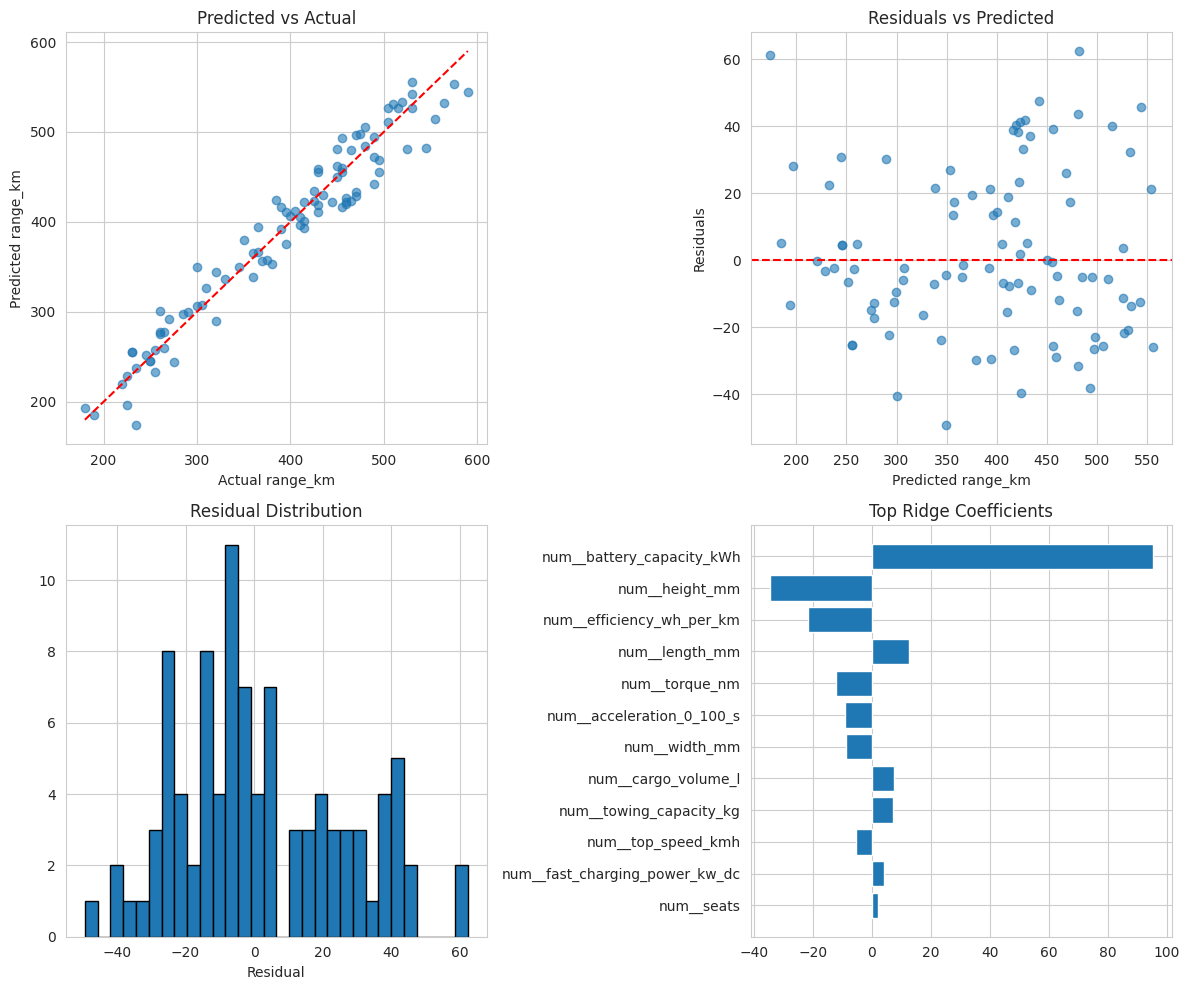

In [206]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = pipe.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Predicted vs Actual
axes[0,0].scatter(y_test, y_pred, alpha=0.6)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,0].set_xlabel("Actual range_km")
axes[0,0].set_ylabel("Predicted range_km")
axes[0,0].set_title("Predicted vs Actual")

# 2. Residuals vs Predicted
axes[0,1].scatter(y_pred, residuals, alpha=0.6)
axes[0,1].axhline(0, color='r', linestyle='--')
axes[0,1].set_xlabel("Predicted range_km")
axes[0,1].set_ylabel("Residuals")
axes[0,1].set_title("Residuals vs Predicted")

# 3. Residual distribution
axes[1,0].hist(residuals, bins=30, edgecolor='black')
axes[1,0].set_xlabel("Residual")
axes[1,0].set_title("Residual Distribution")

# 4. Ridge coefficients (only works cleanly if you extract feature names from ColumnTransformer)
feature_names = pipe.named_steps["prep"].get_feature_names_out()
coefs = pipe.named_steps["ridge"].coef_
order = np.argsort(np.abs(coefs))[::-1][:15]  # top 15
axes[1,1].barh(np.array(feature_names)[order][::-1], coefs[order][::-1])
axes[1,1].set_title("Top Ridge Coefficients")

plt.tight_layout()
plt.show()

In [207]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import joblib

# Hyperparameter tuning
param_grid = {"ridge__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}

grid_search = GridSearchCV(
    pipe, param_grid, cv=5, scoring="r2", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

best_pipe = grid_search.best_estimator_

# Evaluate on test set
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_pipe.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²:", r2_score(y_test, y_pred))

# Save the trained pipeline
joblib.dump(best_pipe, "ridge_range_model.pkl")
print("Model saved as ridge_range_model.pkl")

Best alpha: {'ridge__alpha': 1.0}
Best CV R²: 0.9435191506843574
Test MAE: 19.862963757608757
Test RMSE: 24.61590717346268
Test R²: 0.9427370411947842
Model saved as ridge_range_model.pkl


In [208]:
from google.colab import files
files.download("ridge_range_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [209]:
loaded_pipe = joblib.load("ridge_range_model.pkl")
loaded_pipe.predict(X_test)

array([505.61641748, 468.985016  , 173.63706609, 421.69289822,
       421.79801213, 289.66995173, 406.70225888, 366.33761495,
       299.55743104, 307.47279387, 526.2142168 , 297.56239337,
       193.42822684, 484.93040263, 255.22443846, 364.96131654,
       526.4325715 , 232.57496419, 255.22443846, 449.8707093 ,
       257.6149734 , 196.81432503, 424.53147808, 426.69625557,
       228.36439071, 497.81807786, 553.80434587, 306.00822045,
       393.63666588, 532.66234221, 429.88936864, 326.49208847,
       244.28396336, 260.30138197, 353.14773922, 514.92951274,
       396.4981385 , 419.66337692, 455.78259804, 338.39003434,
       411.10842422, 442.62914483, 349.55897771, 481.56190467,
       423.22977557, 357.72979721, 480.26314213, 277.31774928,
       245.60350641, 555.81360903, 461.81493039, 421.6081956 ,
       412.61229334, 533.8419817 , 343.94885337, 459.71967217,
       458.82409114, 349.35857342, 510.5991188 , 481.34236826,
       379.70403544, 423.70566267, 184.83037463, 418.49

# K-Mean Clustering

In [210]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

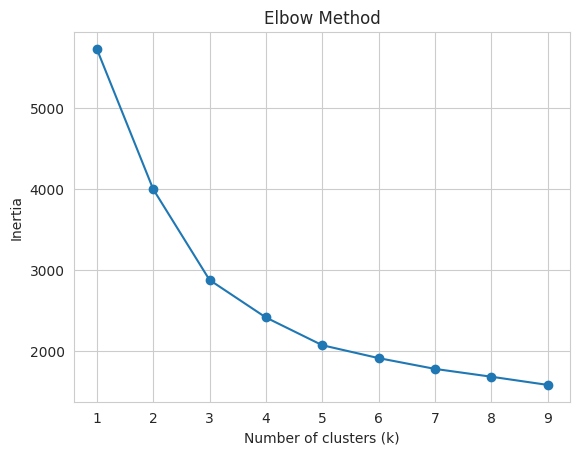

In [211]:
# --- 1. Elbow Plot (Inertia vs k) ---
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [212]:
best_k = 4;

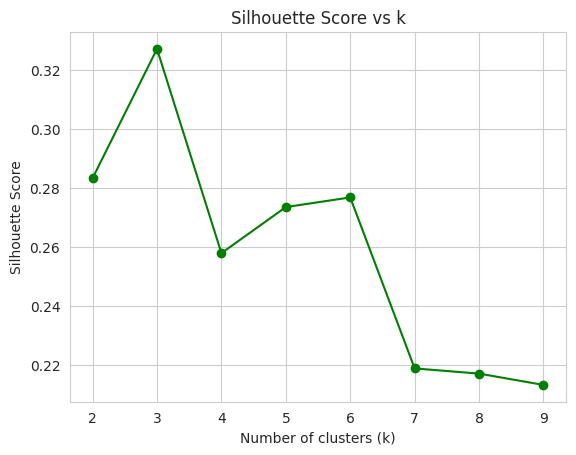

Best k: 3


In [213]:
# --- 2. Silhouette Score vs k ---
from sklearn.metrics import silhouette_score, silhouette_samples

sil_scores = []
k_range2 = range(2, 10)
for k in k_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(list(k_range2), sil_scores, marker='o', color='green')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

best_k = list(k_range2)[sil_scores.index(max(sil_scores))]
print("Best k:", best_k)

In [214]:
# --- 3. Fit final KMeans with best_k ---
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df["cluster"] = clusters

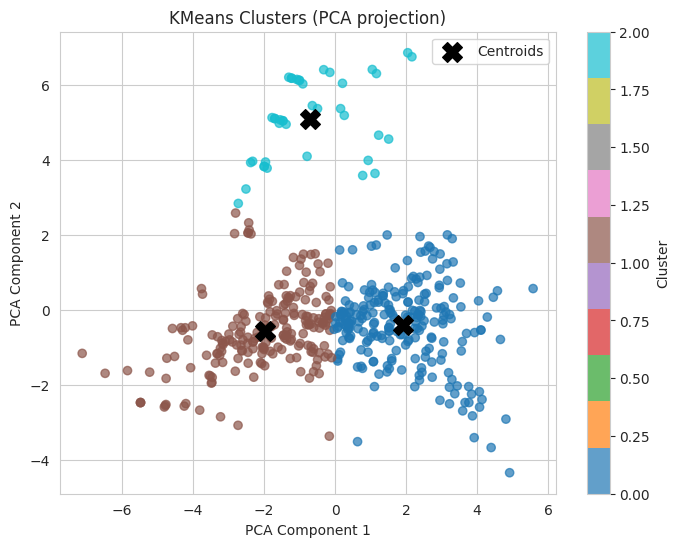

In [215]:
# --- 4. PCA 2D scatter of clusters ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="tab10", alpha=0.7)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c="black", marker="X", s=200, label="Centroids")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clusters (PCA projection)")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()

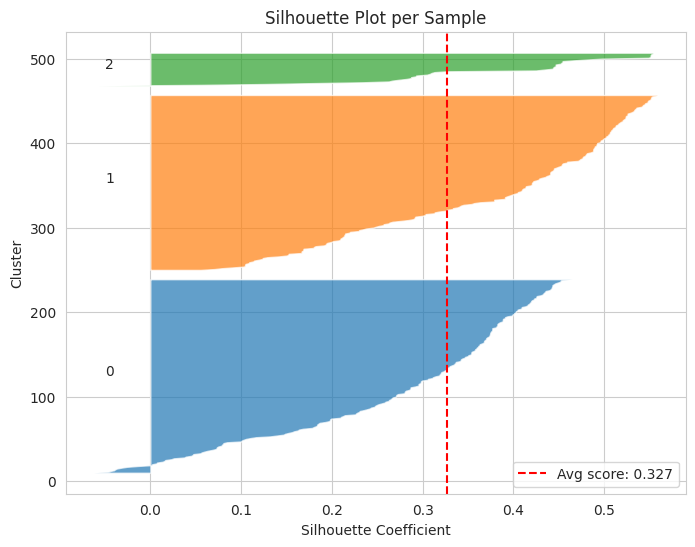

In [216]:
# --- 5. Per-sample Silhouette Plot ---
import numpy as np

sample_silhouette_values = silhouette_samples(X_scaled, clusters)
avg_score = silhouette_score(X_scaled, clusters)

fig, ax = plt.subplots(figsize=(8,6))
y_lower = 10
for i in range(best_k):
    ith_values = sample_silhouette_values[clusters == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5*size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Avg score: {avg_score:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot per Sample")
ax.legend()
plt.show()

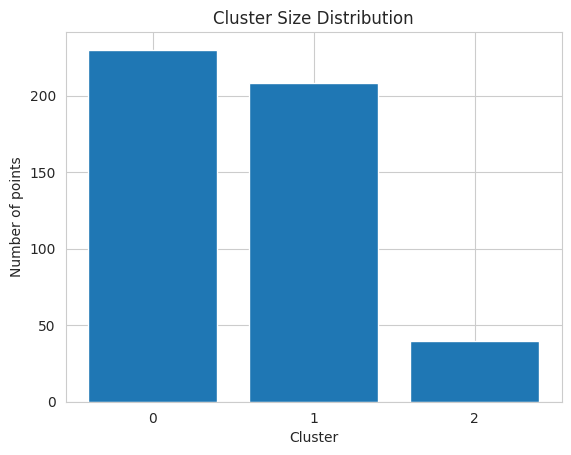

In [217]:
# --- 6. Cluster size distribution ---
cluster_counts = df["cluster"].value_counts().sort_index()
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of points")
plt.title("Cluster Size Distribution")
plt.show()

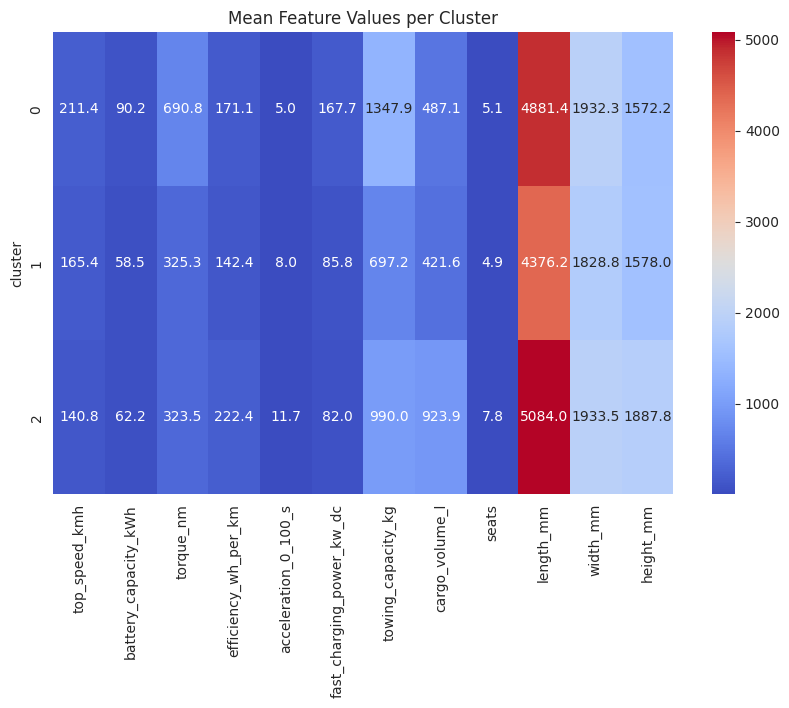

In [218]:
# --- 7. Cluster feature-mean heatmap (helps interpret what each cluster represents) ---
import seaborn as sns

numeric_cols = X.select_dtypes(include="number").columns  # adjust to your numeric feature list
cluster_means = df.groupby("cluster")[numeric_cols].mean()

plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Mean Feature Values per Cluster")
plt.show()

k=2, silhouette=0.2833
k=3, silhouette=0.3271
k=4, silhouette=0.2579
k=5, silhouette=0.2735
k=6, silhouette=0.2768
k=7, silhouette=0.2189
k=8, silhouette=0.2172
k=9, silhouette=0.2133


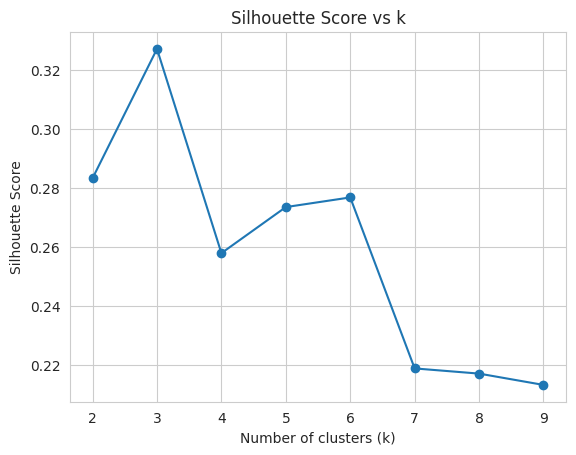

Best k by silhouette: 3


In [219]:
# --- KMeans with Silhouette Score validation ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X)

silhouette_scores = []
k_range = range(2, 10)  # silhouette needs at least 2 clusters

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

plt.plot(list(k_range), silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print("Best k by silhouette:", best_k)

In [220]:
# --- Fit final KMeans with best k ---
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df["cluster"] = clusters

print("Final silhouette score:", silhouette_score(X_scaled, clusters))

Final silhouette score: 0.3270649646301041


In [221]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil = silhouette_score(X_scaled, clusters)
db = davies_bouldin_score(X_scaled, clusters)
ch = calinski_harabasz_score(X_scaled, clusters)

print(f"Silhouette Score: {sil:.4f}   (higher is better, range -1 to 1)")
print(f"Davies-Bouldin Index: {db:.4f}   (lower is better)")
print(f"Calinski-Harabasz Index: {ch:.4f}   (higher is better)")

Silhouette Score: 0.3271   (higher is better, range -1 to 1)
Davies-Bouldin Index: 1.0461   (lower is better)
Calinski-Harabasz Index: 235.8579   (higher is better)


In [222]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [223]:
# --- Save KMeans model ---
import joblib

joblib.dump(kmeans_final, "kmeans_model.pkl")
joblib.dump(scaler, "scaler_for_clustering.pkl")  # save scaler too, needed for new data
print("KMeans model saved as kmeans_model.pkl")

KMeans model saved as kmeans_model.pkl


# DBSCAN


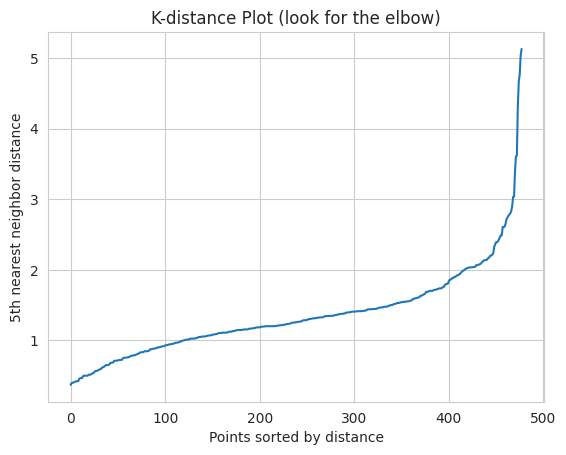

In [224]:
# --- 1. K-distance plot (helps choose eps) ---
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.ylabel(f"{min_samples}th nearest neighbor distance")
plt.xlabel("Points sorted by distance")
plt.title("K-distance Plot (look for the elbow)")
plt.show()

In [225]:
# --- 2. Fit DBSCAN with chosen eps ---
from sklearn.cluster import DBSCAN

eps = 0.5  # set from the elbow above
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print("Clusters found:", n_clusters)
print("Noise points:", n_noise, f"({n_noise/len(db_labels)*100:.1f}%)")

Clusters found: 4
Noise points: 449 (93.9%)


In [226]:
# --- 3. Validation metrics (excluding noise points) ---
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

mask = db_labels != -1

if n_clusters >= 2:
    sil = silhouette_score(X_scaled[mask], db_labels[mask])
    db_idx = davies_bouldin_score(X_scaled[mask], db_labels[mask])
    ch_idx = calinski_harabasz_score(X_scaled[mask], db_labels[mask])
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies-Bouldin Index: {db_idx:.4f}")
    print(f"Calinski-Harabasz Index: {ch_idx:.4f}")
else:
    print("Not enough clusters for validation metrics.")

Silhouette Score: 0.5109
Davies-Bouldin Index: 0.6836
Calinski-Harabasz Index: 249.2779


In [227]:
# --- 4. Compare across eps values ---
import pandas as pd

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_pts = (labels == -1).sum()
    row = {"eps": eps, "clusters": n_clust, "noise_points": n_noise_pts}
    if n_clust >= 2:
        m = labels != -1
        row["silhouette"] = silhouette_score(X_scaled[m], labels[m])
        row["davies_bouldin"] = davies_bouldin_score(X_scaled[m], labels[m])
        row["calinski_harabasz"] = calinski_harabasz_score(X_scaled[m], labels[m])
    results.append(row)

results_df = pd.DataFrame(results)
print(results_df)

   eps  clusters  noise_points  silhouette  davies_bouldin  calinski_harabasz
0  0.3         0           478         NaN             NaN                NaN
1  0.5         4           449    0.510865        0.683569         249.277851
2  0.7         8           408    0.506887        0.747057         168.656301
3  1.0         7           319    0.105903        1.083393          49.361213
4  1.5         8            92    0.035135        1.002740          37.821943
5  2.0         8            30   -0.009414        0.868956          20.228774


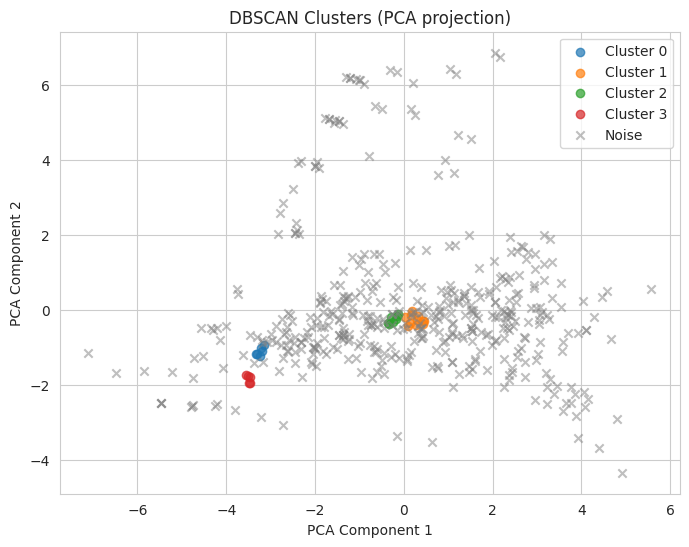

In [228]:
# --- 5. PCA 2D scatter of DBSCAN clusters (noise shown separately) ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
unique_labels = set(db_labels)
for label in unique_labels:
    mask_l = db_labels == label
    if label == -1:
        plt.scatter(X_pca[mask_l,0], X_pca[mask_l,1], c="gray", marker="x", alpha=0.5, label="Noise")
    else:
        plt.scatter(X_pca[mask_l,0], X_pca[mask_l,1], alpha=0.7, label=f"Cluster {label}")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clusters (PCA projection)")
plt.legend()
plt.show()

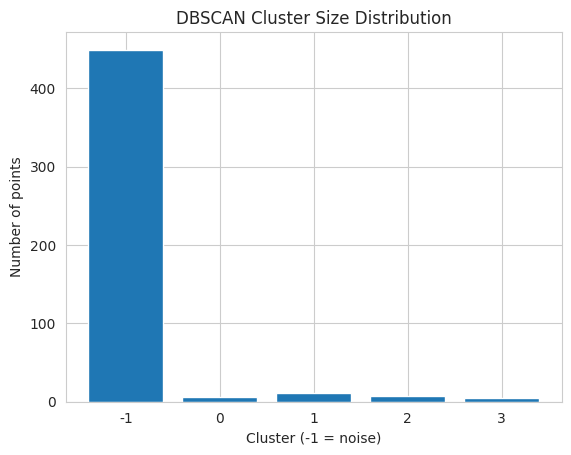

In [229]:
# --- 6. Cluster size distribution (including noise) ---
cluster_counts = pd.Series(db_labels).value_counts().sort_index()
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("Cluster (-1 = noise)")
plt.ylabel("Number of points")
plt.title("DBSCAN Cluster Size Distribution")
plt.show()

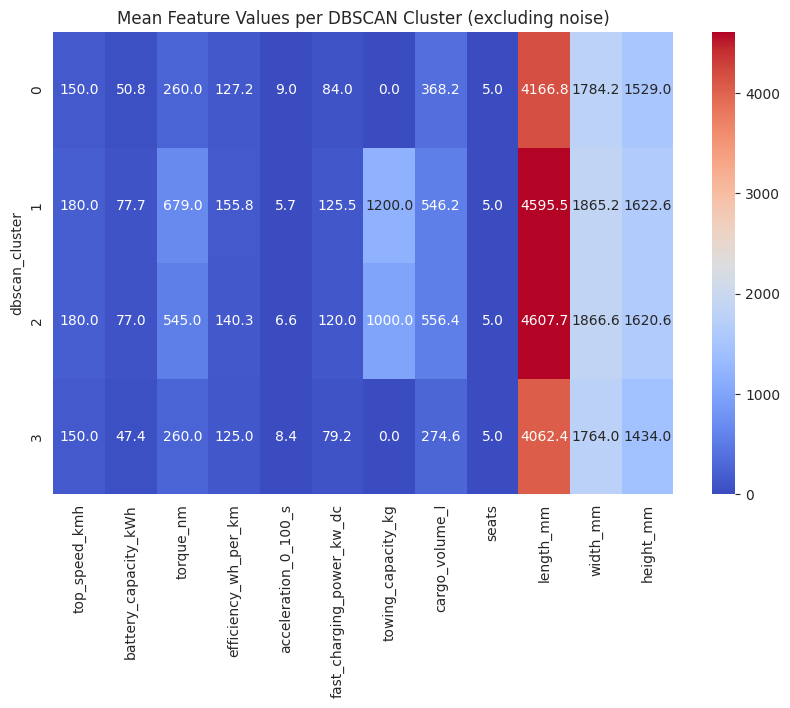

In [230]:
# --- 7. Cluster feature-mean heatmap (excluding noise) ---
import seaborn as sns

numeric_cols = X.select_dtypes(include="number").columns
df_clean = df[df["dbscan_cluster"] != -1]
cluster_means = df_clean.groupby("dbscan_cluster")[numeric_cols].mean()

plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Mean Feature Values per DBSCAN Cluster (excluding noise)")
plt.show()

In [231]:
from sklearn.metrics import silhouette_score

mask = db_labels != -1  # exclude noise points
sil = silhouette_score(X_scaled[mask], db_labels[mask])
print("Silhouette Score for trained DBSCAN model:", sil)

Silhouette Score for trained DBSCAN model: 0.5108647537071915


In [232]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.3, 0.5, 0.7, 1.0, 1.3, 1.5, 1.8, 2.0]
min_samples = 5

sil_scores = []
valid_eps = []

for e in eps_values:
    db = DBSCAN(eps=e, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters >= 2:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        sil_scores.append(score)
        valid_eps.append(e)

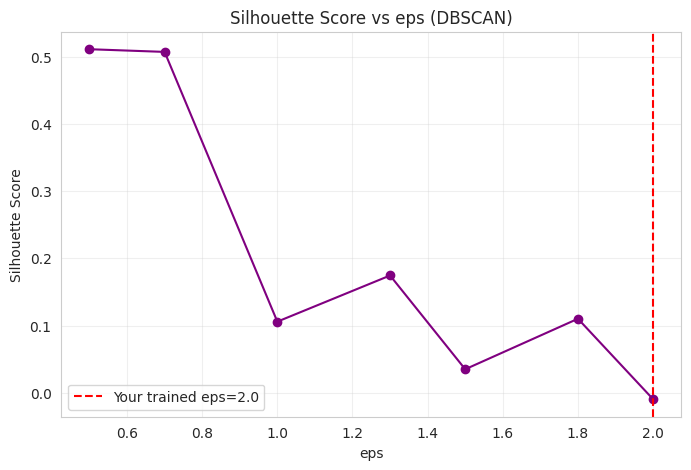

In [233]:
plt.figure(figsize=(8,5))
plt.plot(valid_eps, sil_scores, marker='o', color='purple')
plt.axvline(x=eps, color='red', linestyle='--', label=f"Your trained eps={eps}")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs eps (DBSCAN)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [234]:
# --- Save DBSCAN model ---
joblib.dump(dbscan, "dbscan_model.pkl")
print("DBSCAN model saved as dbscan_model.pkl")

DBSCAN model saved as dbscan_model.pkl


# Random Forest


In [235]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_pipe.fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 13.54209015376984
RMSE: 19.10902238982406
R²: 0.965492060177712


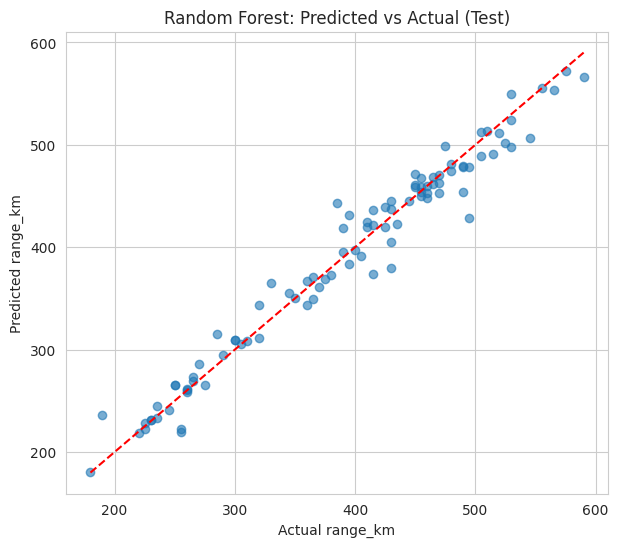

In [236]:
# --- 1. Predicted vs Actual (Test set) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual range_km")
plt.ylabel("Predicted range_km")
plt.title("Random Forest: Predicted vs Actual (Test)")
plt.show()

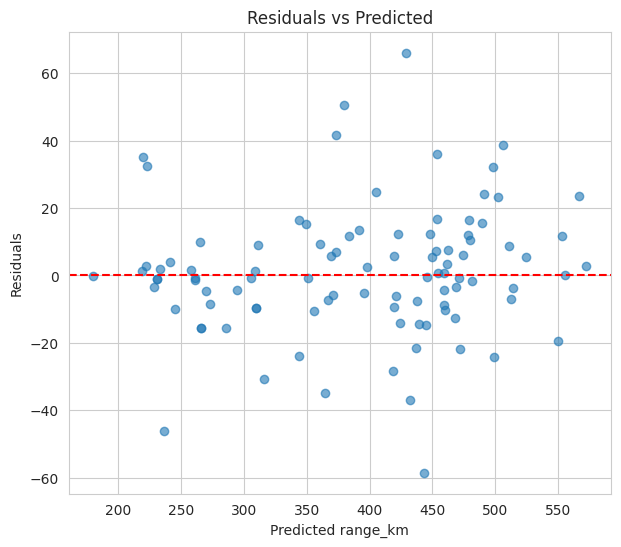

In [237]:
# --- 2. Residuals vs Predicted ---
residuals = y_test - y_pred

plt.figure(figsize=(7,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted range_km")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

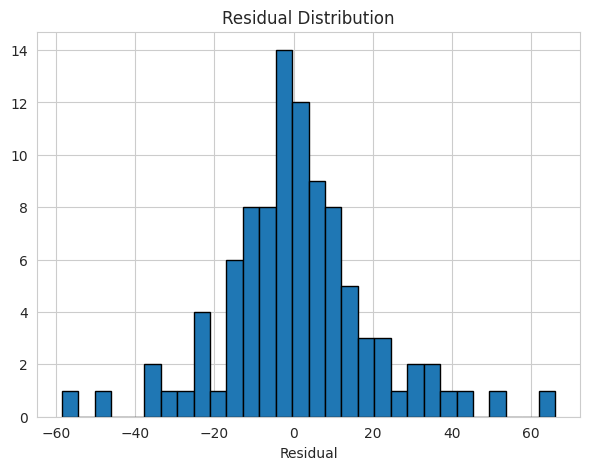

In [238]:
# --- 3. Residual Distribution ---
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

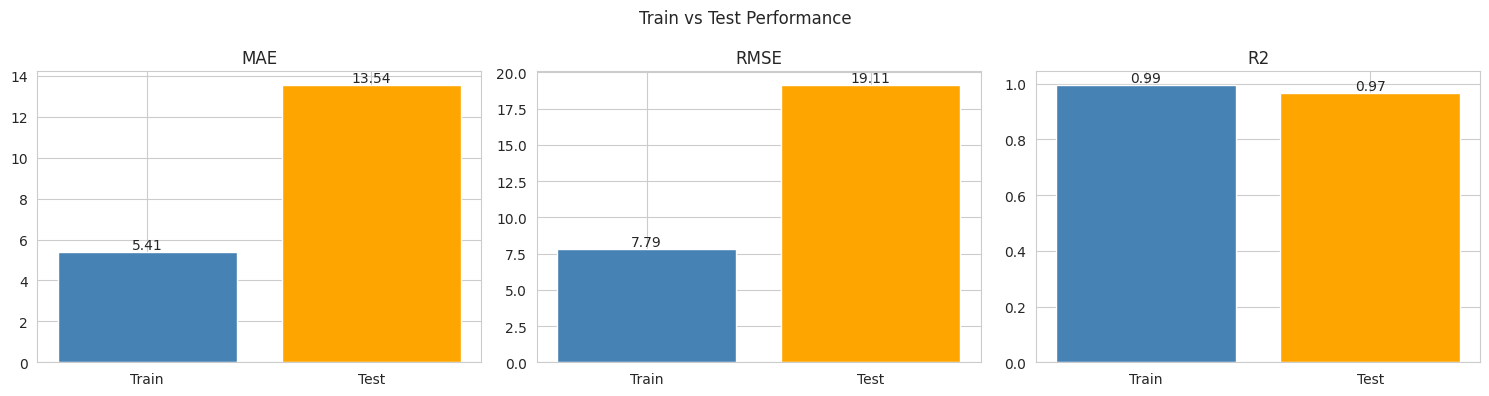

Train R²: 0.9943  |  Test R²: 0.9655


In [239]:
# --- 4. Train vs Test performance (overfitting check) ---
y_train_pred = rf_pipe.predict(X_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

metrics = {
    "MAE": [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred)), np.sqrt(mean_squared_error(y_test, y_pred))],
    "R2": [r2_score(y_train, y_train_pred), r2_score(y_test, y_pred)]
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
labels = ["Train", "Test"]
for ax, (name, vals) in zip(axes, metrics.items()):
    ax.bar(labels, vals, color=["steelblue", "orange"])
    ax.set_title(name)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.suptitle("Train vs Test Performance")
plt.tight_layout()
plt.show()

print(f"Train R²: {metrics['R2'][0]:.4f}  |  Test R²: {metrics['R2'][1]:.4f}")

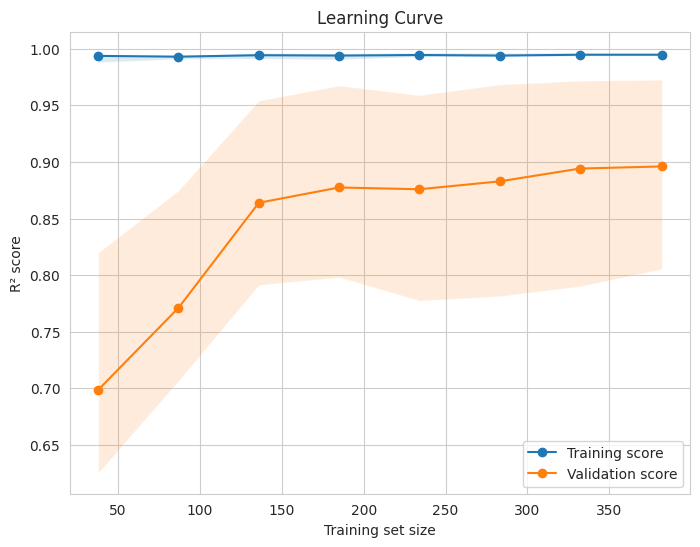

In [240]:
# --- 5. Learning Curve (training size vs performance) ---
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_pipe, X, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, val_mean, 'o-', label="Validation score")
plt.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.15)
plt.fill_between(train_sizes, val_scores.min(axis=1), val_scores.max(axis=1), alpha=0.15)
plt.xlabel("Training set size")
plt.ylabel("R² score")
plt.title("Learning Curve")
plt.legend()
plt.show()

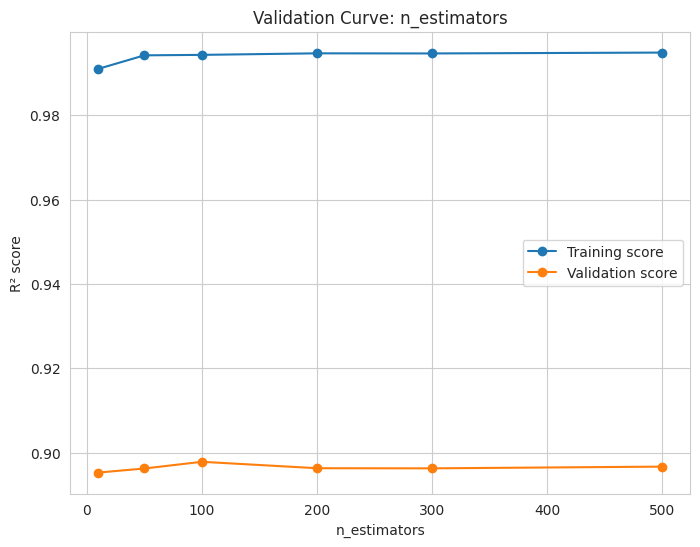

In [241]:
# --- 6. Validation Curve (n_estimators tuning) ---
from sklearn.model_selection import validation_curve

param_range = [10, 50, 100, 200, 300, 500]
train_scores_vc, val_scores_vc = validation_curve(
    rf_pipe, X, y,
    param_name="rf__n_estimators", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_scores_vc.mean(axis=1), 'o-', label="Training score")
plt.plot(param_range, val_scores_vc.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("n_estimators")
plt.ylabel("R² score")
plt.title("Validation Curve: n_estimators")
plt.legend()
plt.show()

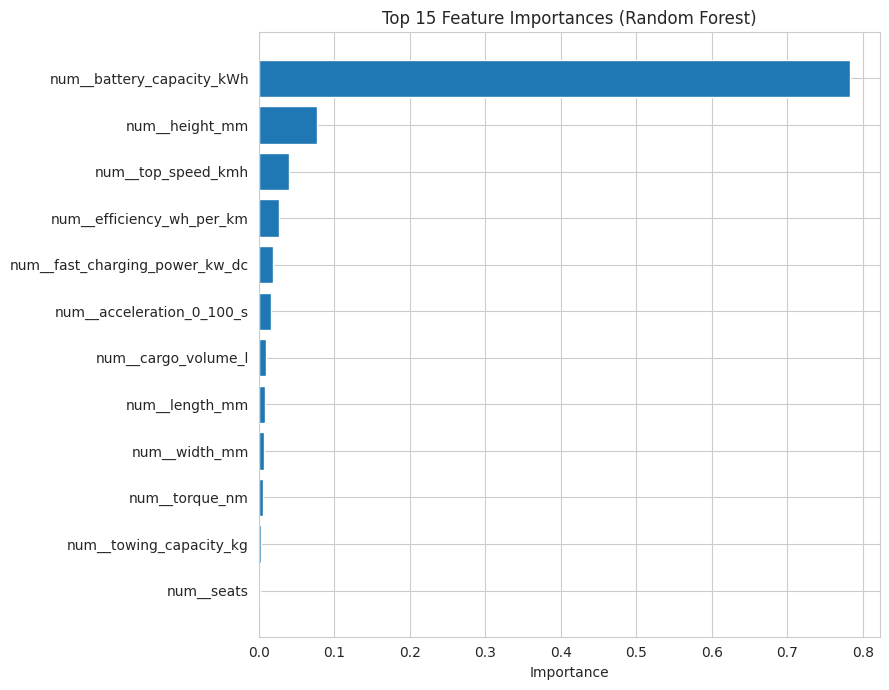

In [242]:
# --- 7. Feature Importance ---
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["rf"].feature_importances_

order = np.argsort(importances)[::-1][:15]  # top 15
plt.figure(figsize=(9,7))
plt.barh(np.array(feature_names)[order][::-1], importances[order][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

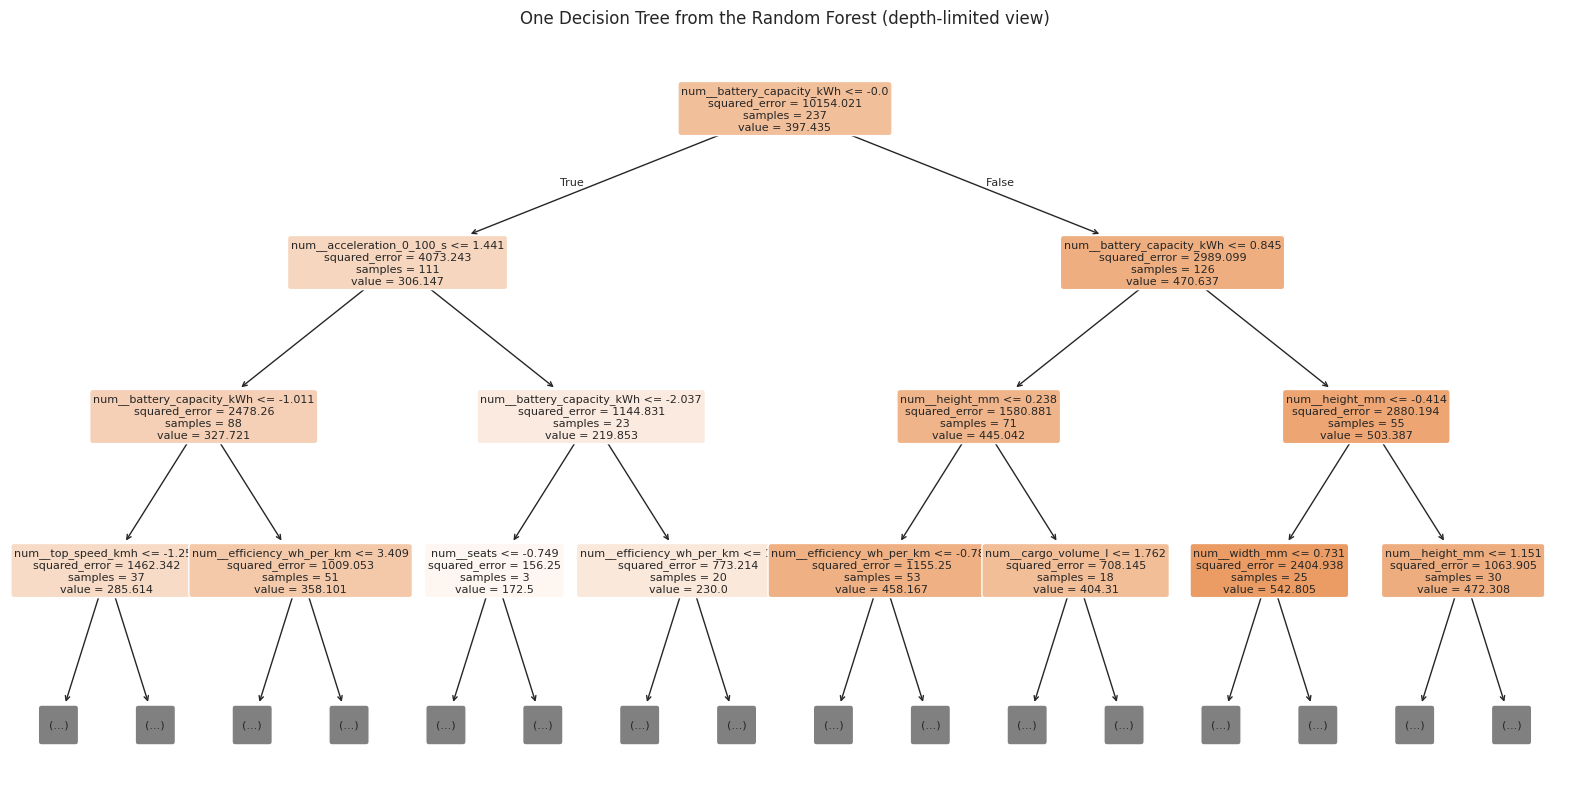

In [243]:
# --- Visualize one tree from the Random Forest ---
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
single_tree = rf_pipe.named_steps["rf"].estimators_[0]  # pick any tree, e.g. the first

plt.figure(figsize=(20,10))
plot_tree(
    single_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,   # limit depth so it's actually readable; remove this to see full tree
    fontsize=8
)
plt.title("One Decision Tree from the Random Forest (depth-limited view)")
plt.show()

In [244]:
# --- Save Random Forest pipeline ---
import joblib

joblib.dump(rf_pipe, "random_forest_range_model.pkl")
print("Model saved as random_forest_range_model.pkl")

Model saved as random_forest_range_model.pkl


In [245]:
# --- Download from Colab ---
from google.colab import files

files.download("random_forest_range_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Decision tree


In [246]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_pipe = Pipeline([
    ("prep", preprocessor),
    ("dt", DecisionTreeRegressor(random_state=42, max_depth=6))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R²:", r2_score(y_test, y_pred_dt))

MAE: 18.87801927732578
RMSE: 24.894929995781954
R²: 0.9414315255201688


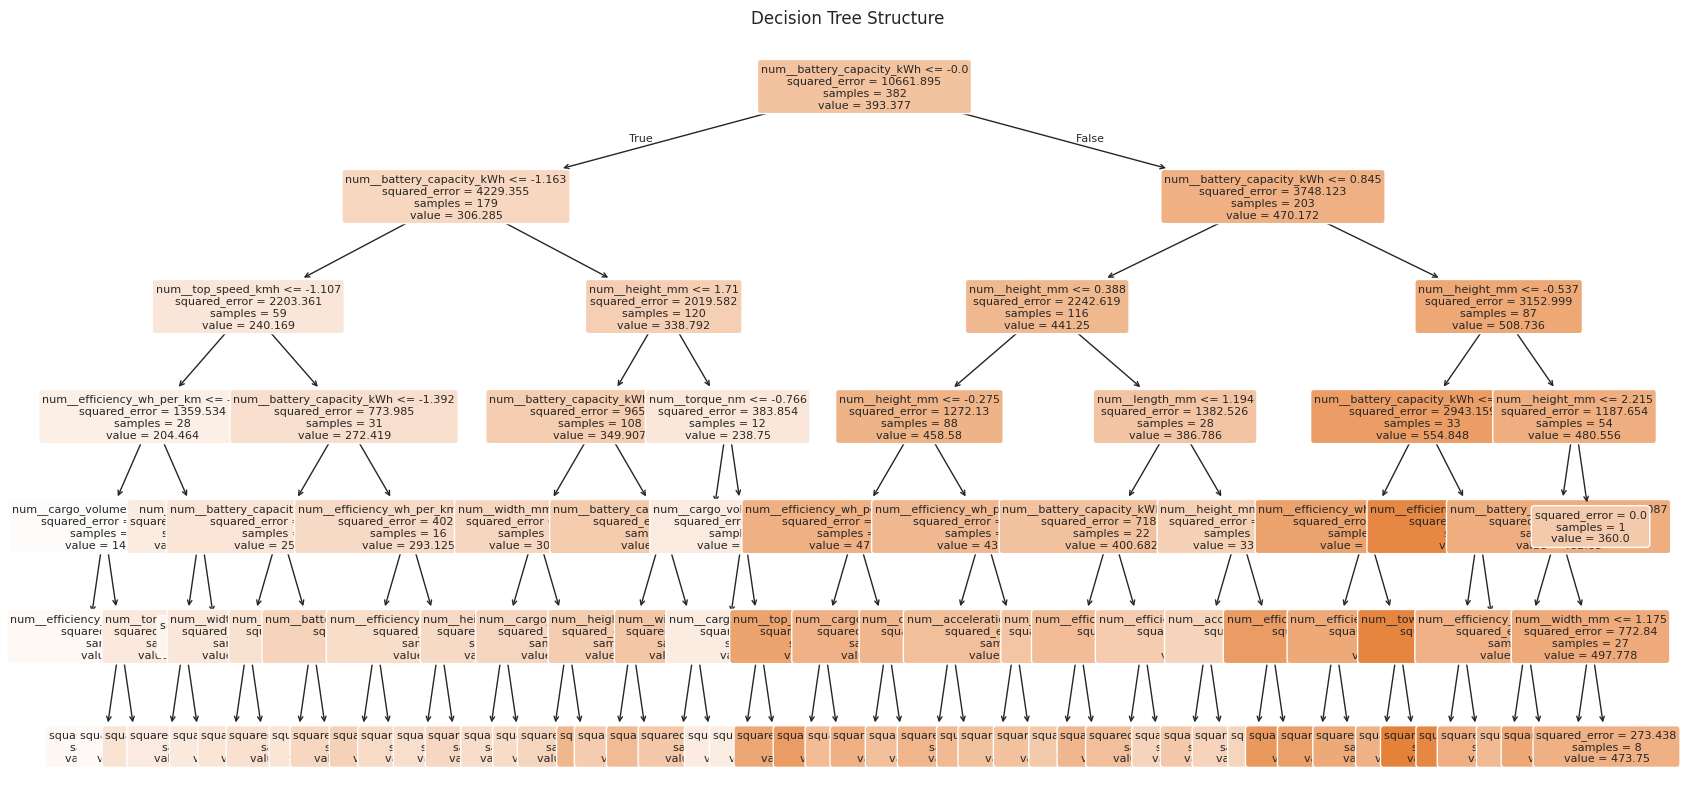

In [247]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = dt_pipe.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(20,10))
plot_tree(dt_pipe.named_steps["dt"], feature_names=feature_names, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Structure")
plt.show()

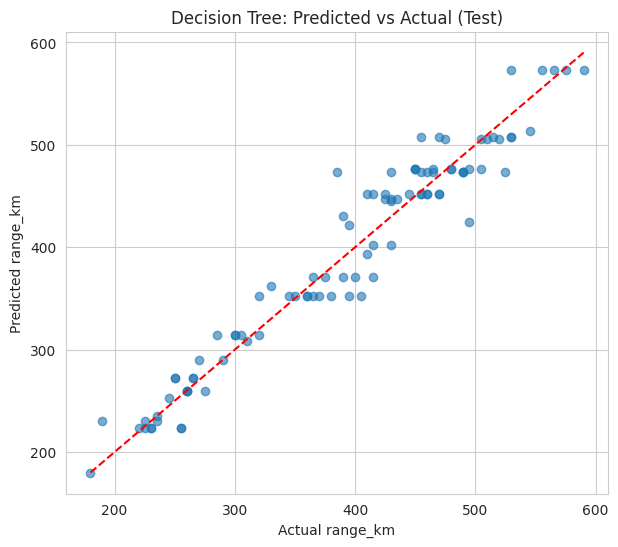

In [248]:
# --- 1. Predicted vs Actual (Test set) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual range_km")
plt.ylabel("Predicted range_km")
plt.title("Decision Tree: Predicted vs Actual (Test)")
plt.show()

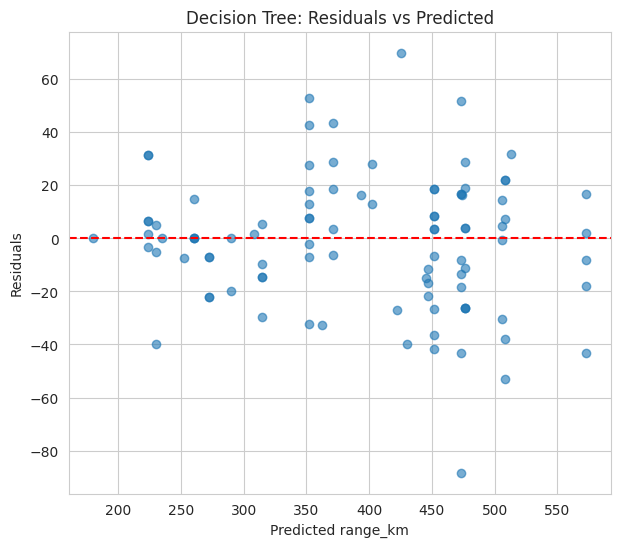

In [249]:
# --- 2. Residuals vs Predicted ---
residuals_dt = y_test - y_pred_dt

plt.figure(figsize=(7,6))
plt.scatter(y_pred_dt, residuals_dt, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted range_km")
plt.ylabel("Residuals")
plt.title("Decision Tree: Residuals vs Predicted")
plt.show()

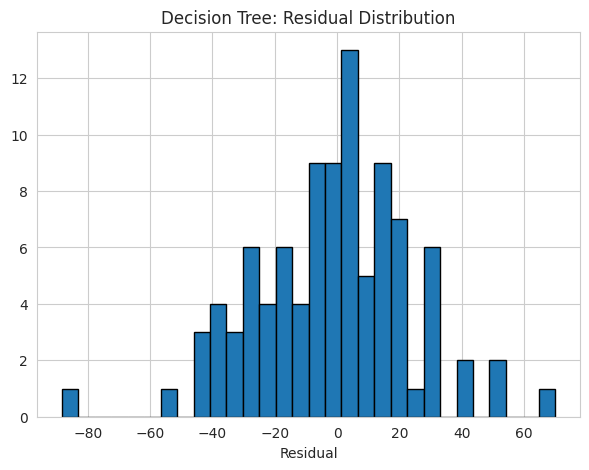

In [250]:
# --- 3. Residual Distribution ---
plt.figure(figsize=(7,5))
plt.hist(residuals_dt, bins=30, edgecolor='black')
plt.xlabel("Residual")
plt.title("Decision Tree: Residual Distribution")
plt.show()

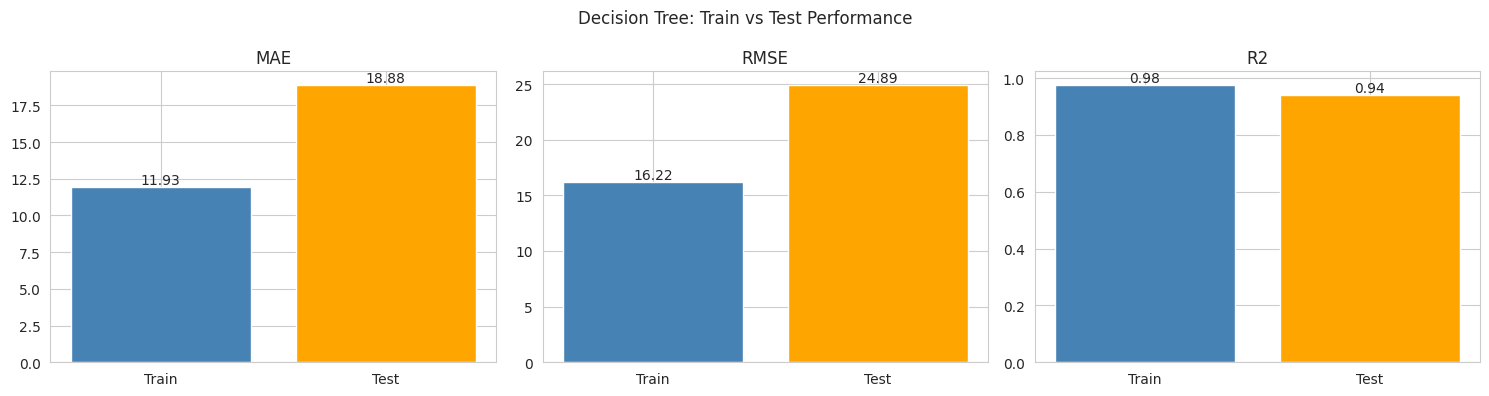

In [251]:
# --- 4. Train vs Test performance bars ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred_dt = dt_pipe.predict(X_train)

metrics_dt = {
    "MAE": [mean_absolute_error(y_train, y_train_pred_dt), mean_absolute_error(y_test, y_pred_dt)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred_dt)), np.sqrt(mean_squared_error(y_test, y_pred_dt))],
    "R2": [r2_score(y_train, y_train_pred_dt), r2_score(y_test, y_pred_dt)]
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
labels = ["Train", "Test"]
for ax, (name, vals) in zip(axes, metrics_dt.items()):
    ax.bar(labels, vals, color=["steelblue", "orange"])
    ax.set_title(name)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.suptitle("Decision Tree: Train vs Test Performance")
plt.tight_layout()
plt.show()

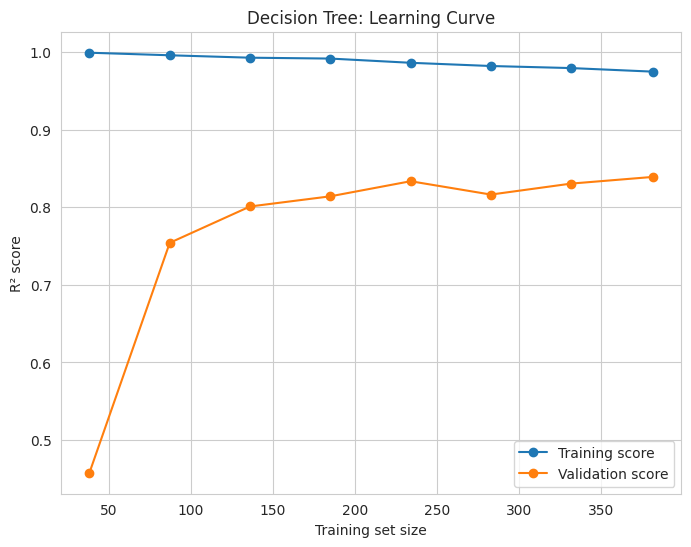

In [252]:
# --- 5. Learning Curve ---
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    dt_pipe, X, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("R² score")
plt.title("Decision Tree: Learning Curve")
plt.legend()
plt.show()

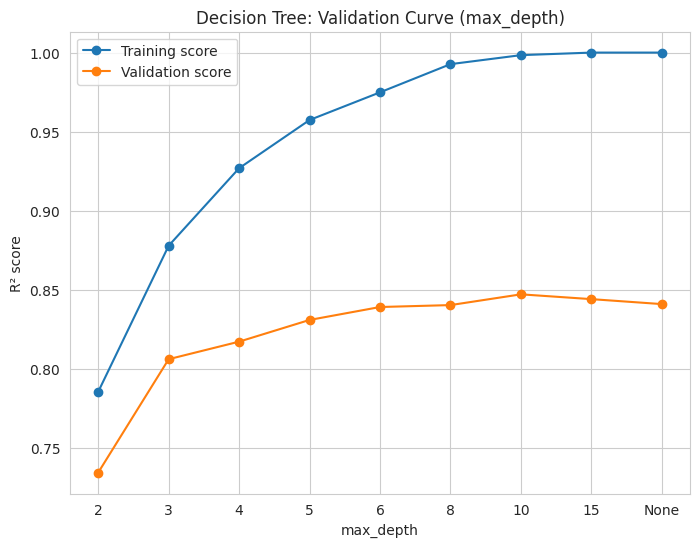

In [253]:
# --- 6. Validation Curve (max_depth tuning) ---
from sklearn.model_selection import validation_curve

param_range = [2, 3, 4, 5, 6, 8, 10, 15, None]
param_range_labels = [str(p) for p in param_range]

train_scores_vc, val_scores_vc = validation_curve(
    dt_pipe, X, y,
    param_name="dt__max_depth", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(param_range_labels, train_scores_vc.mean(axis=1), 'o-', label="Training score")
plt.plot(param_range_labels, val_scores_vc.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("max_depth")
plt.ylabel("R² score")
plt.title("Decision Tree: Validation Curve (max_depth)")
plt.legend()
plt.show()

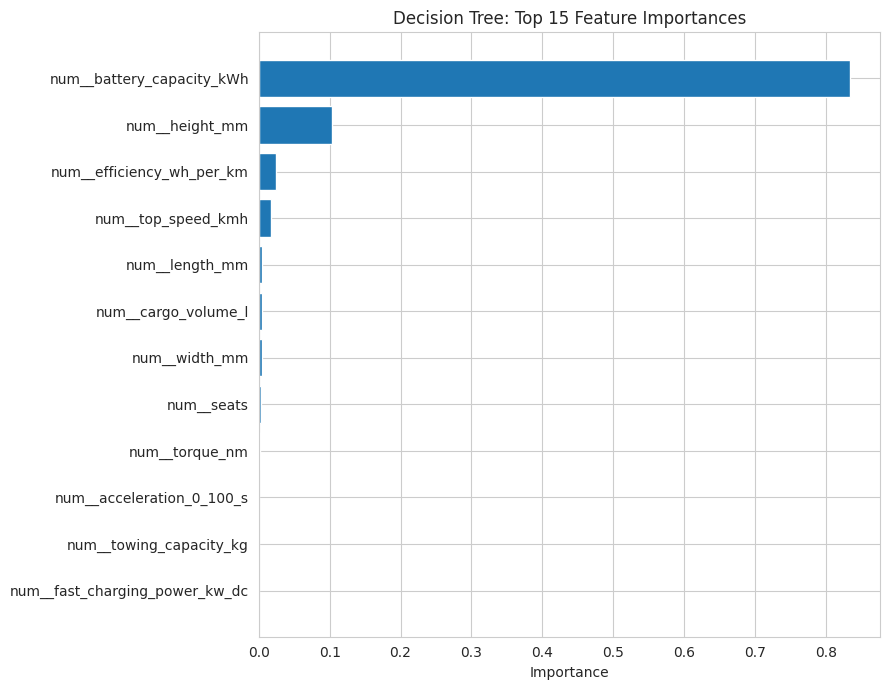

In [254]:
# --- 7. Feature Importance ---
feature_names = dt_pipe.named_steps["prep"].get_feature_names_out()
importances_dt = dt_pipe.named_steps["dt"].feature_importances_

order = np.argsort(importances_dt)[::-1][:15]
plt.figure(figsize=(9,7))
plt.barh(np.array(feature_names)[order][::-1], importances_dt[order][::-1])
plt.xlabel("Importance")
plt.title("Decision Tree: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [255]:
# --- Save Decision Tree pipeline ---
import joblib

joblib.dump(dt_pipe, "decision_tree_range_model.pkl")
print("Model saved as decision_tree_range_model.pkl")

Model saved as decision_tree_range_model.pkl



# Gradient Boost

In [256]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_pipe = Pipeline([
    ("prep", preprocessor),
    ("gb", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R²:", r2_score(y_test, y_pred_gb))

MAE: 13.577502303149993
RMSE: 18.400485977985525
R²: 0.9680036322141559


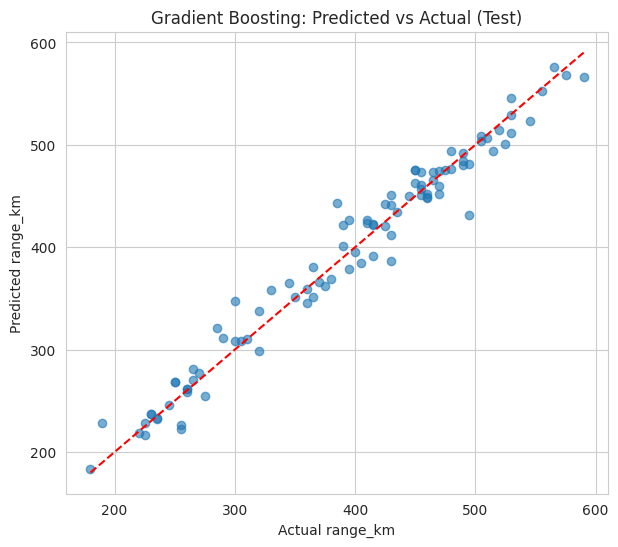

In [257]:
# --- 1. Predicted vs Actual (Test set) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_gb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual range_km")
plt.ylabel("Predicted range_km")
plt.title("Gradient Boosting: Predicted vs Actual (Test)")
plt.show()

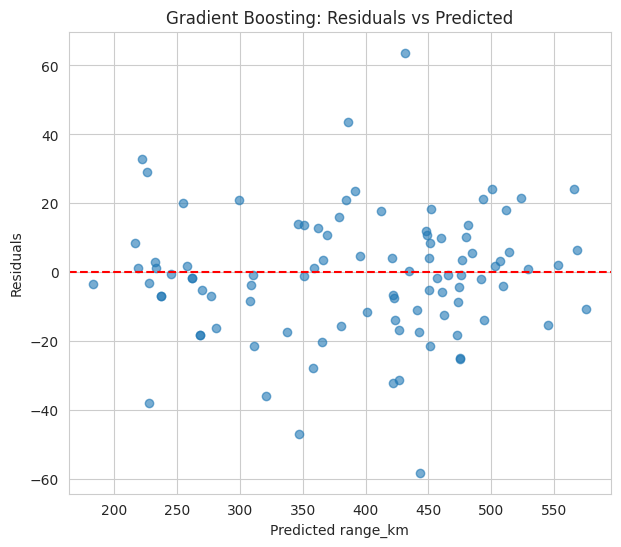

In [258]:
# --- 2. Residuals vs Predicted ---
residuals_gb = y_test - y_pred_gb

plt.figure(figsize=(7,6))
plt.scatter(y_pred_gb, residuals_gb, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted range_km")
plt.ylabel("Residuals")
plt.title("Gradient Boosting: Residuals vs Predicted")
plt.show()

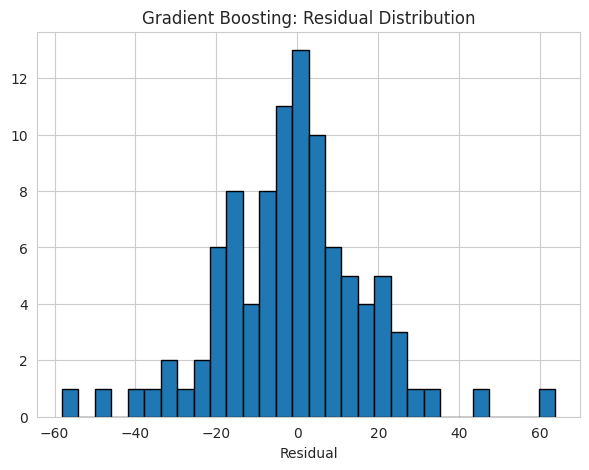

In [259]:
# --- 3. Residual Distribution ---
plt.figure(figsize=(7,5))
plt.hist(residuals_gb, bins=30, edgecolor='black')
plt.xlabel("Residual")
plt.title("Gradient Boosting: Residual Distribution")
plt.show()

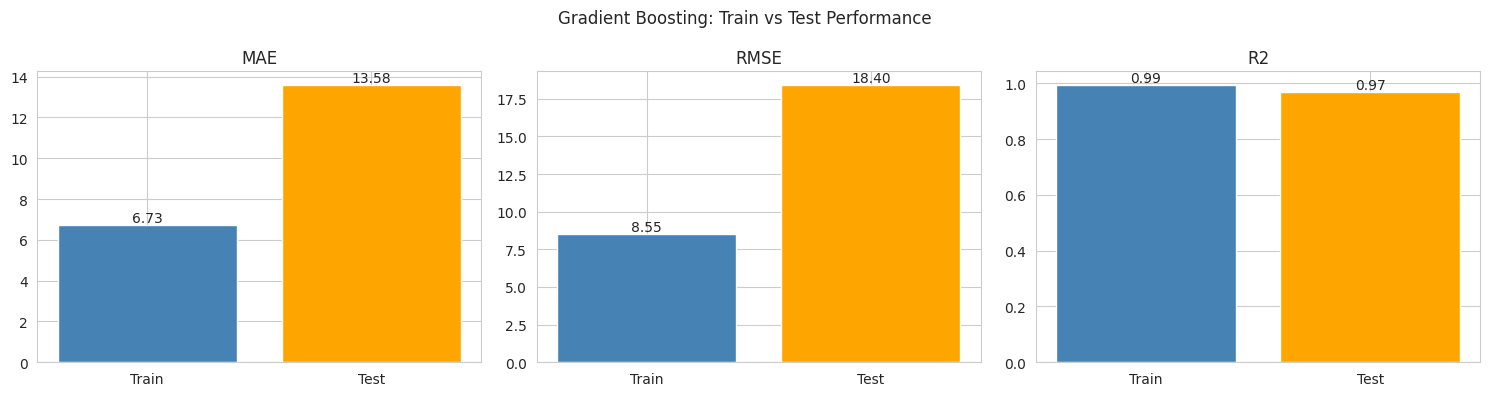

In [260]:
# --- 4. Train vs Test performance bars ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred_gb = gb_pipe.predict(X_train)

metrics_gb = {
    "MAE": [mean_absolute_error(y_train, y_train_pred_gb), mean_absolute_error(y_test, y_pred_gb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred_gb)), np.sqrt(mean_squared_error(y_test, y_pred_gb))],
    "R2": [r2_score(y_train, y_train_pred_gb), r2_score(y_test, y_pred_gb)]
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
labels = ["Train", "Test"]
for ax, (name, vals) in zip(axes, metrics_gb.items()):
    ax.bar(labels, vals, color=["steelblue", "orange"])
    ax.set_title(name)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.suptitle("Gradient Boosting: Train vs Test Performance")
plt.tight_layout()
plt.show()

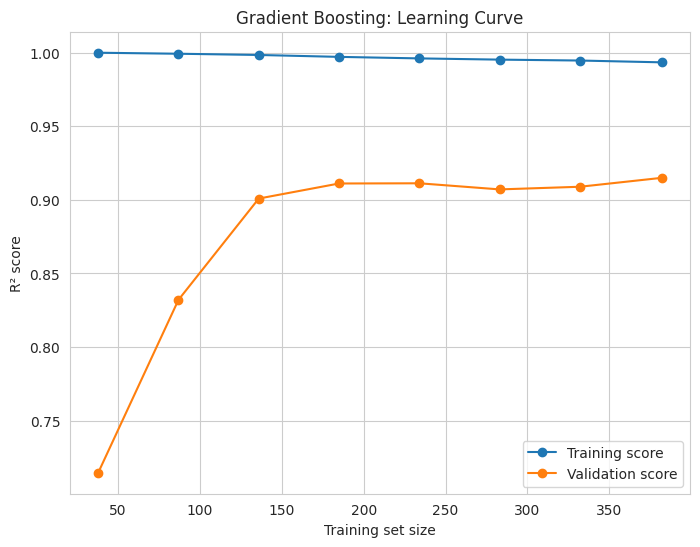

In [261]:
# --- 5. Learning Curve ---
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    gb_pipe, X, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("R² score")
plt.title("Gradient Boosting: Learning Curve")
plt.legend()
plt.show()

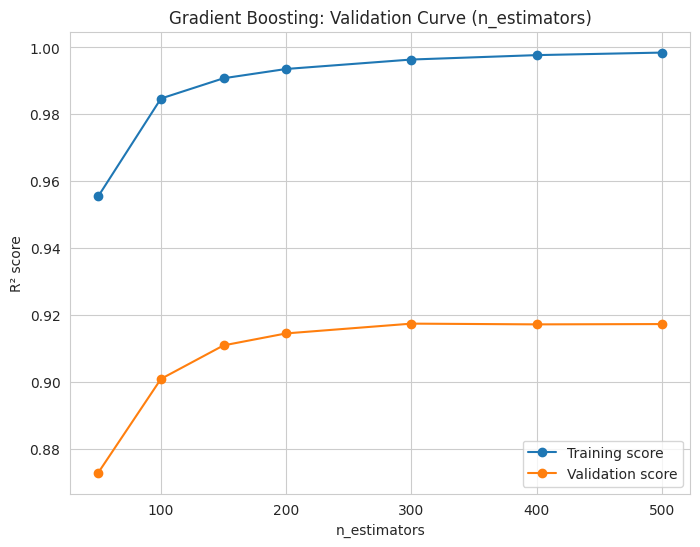

In [262]:
# --- 6. Validation Curve (n_estimators tuning) ---
from sklearn.model_selection import validation_curve

param_range = [50, 100, 150, 200, 300, 400, 500]

train_scores_vc, val_scores_vc = validation_curve(
    gb_pipe, X, y,
    param_name="gb__n_estimators", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_scores_vc.mean(axis=1), 'o-', label="Training score")
plt.plot(param_range, val_scores_vc.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("n_estimators")
plt.ylabel("R² score")
plt.title("Gradient Boosting: Validation Curve (n_estimators)")
plt.legend()
plt.show()

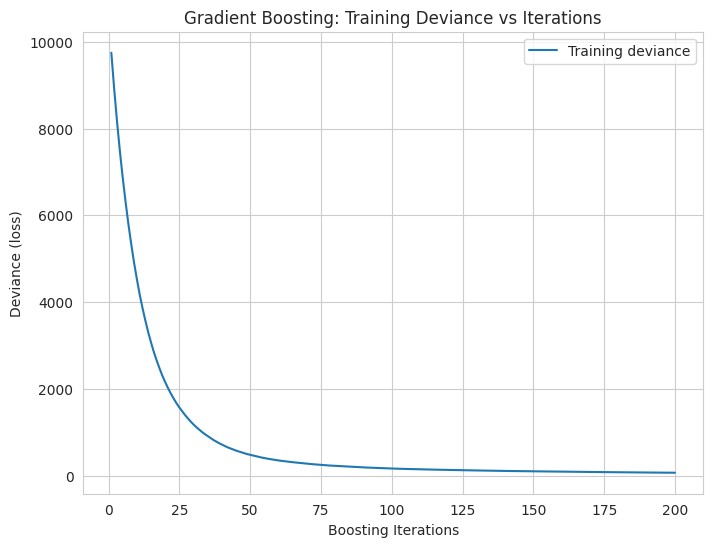

In [263]:
# --- 7. Training Loss / Deviance Curve (unique to Gradient Boosting) ---
train_scores_deviance = gb_pipe.named_steps["gb"].train_score_

plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_scores_deviance)+1), train_scores_deviance, label="Training deviance")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance (loss)")
plt.title("Gradient Boosting: Training Deviance vs Iterations")
plt.legend()
plt.show()

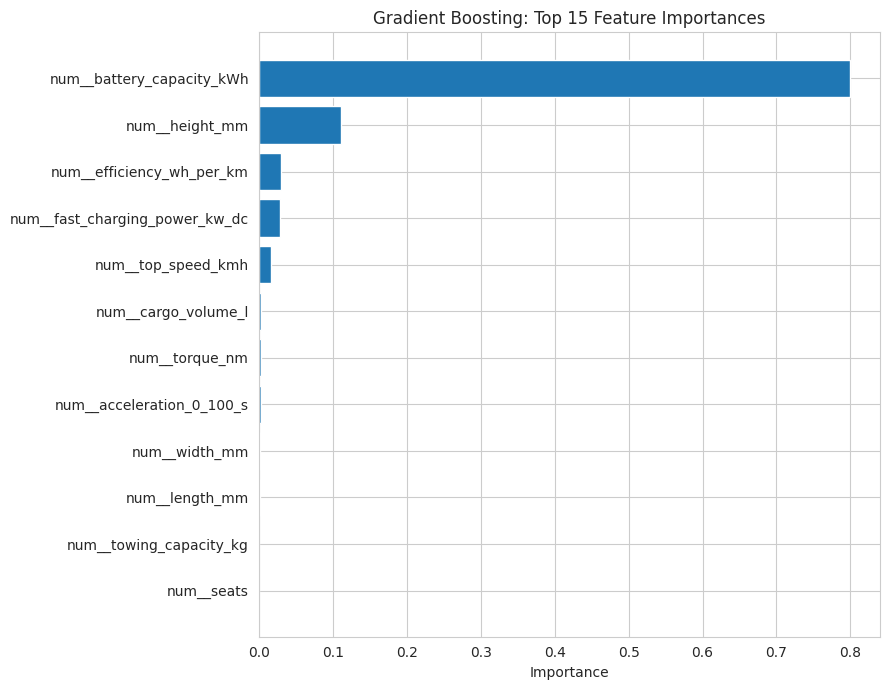

In [264]:
# --- 8. Feature Importance ---
feature_names = gb_pipe.named_steps["prep"].get_feature_names_out()
importances_gb = gb_pipe.named_steps["gb"].feature_importances_

order = np.argsort(importances_gb)[::-1][:15]
plt.figure(figsize=(9,7))
plt.barh(np.array(feature_names)[order][::-1], importances_gb[order][::-1])
plt.xlabel("Importance")
plt.title("Gradient Boosting: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [265]:
# --- Save Gradient Boosting pipeline ---
import joblib

joblib.dump(gb_pipe, "gradient_boosting_range_model.pkl")
print("Model saved as gradient_boosting_range_model.pkl")

Model saved as gradient_boosting_range_model.pkl


# XGBoost


In [266]:
!pip install xgboost==3.2.0

In [267]:
import xgboost
print(xgboost.__file__)
print(xgboost.__version__)

/usr/local/lib/python3.13/dist-packages/xgboost/__init__.py
3.2.0


In [268]:
!pip list | grep -i xgboost

xgboost                               3.2.0


In [269]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R²:", r2_score(y_test, y_pred_xgb))

MAE: 11.33288288116455
RMSE: 15.624058565388427
R²: 0.9769309163093567


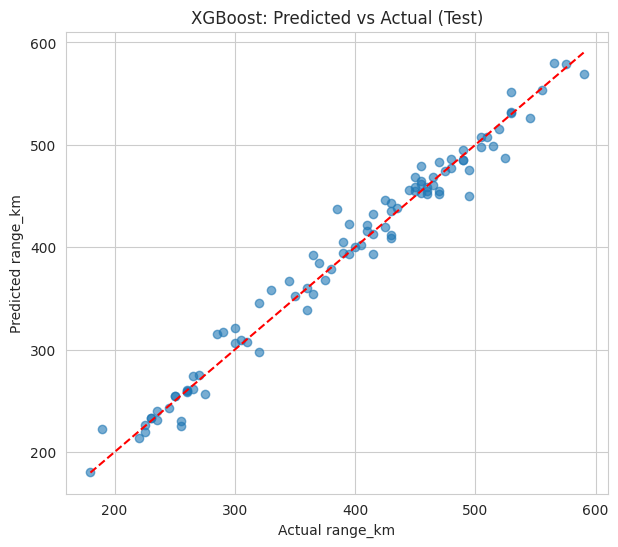

In [270]:
# --- 1. Predicted vs Actual (Test set) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual range_km")
plt.ylabel("Predicted range_km")
plt.title("XGBoost: Predicted vs Actual (Test)")
plt.show()

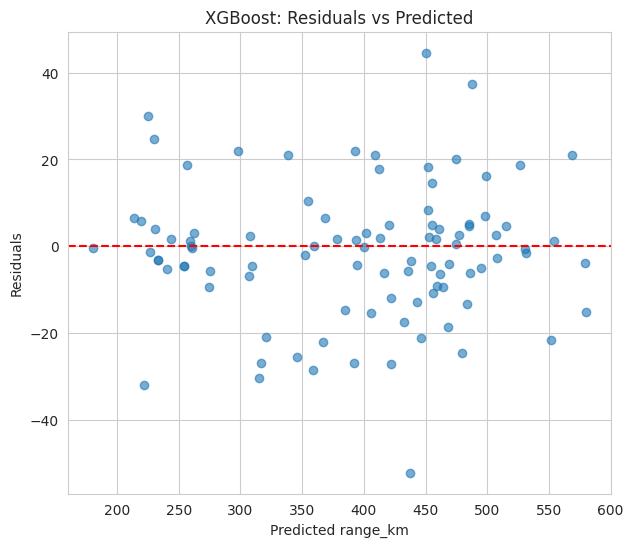

In [271]:
# --- 2. Residuals vs Predicted ---
residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(7,6))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted range_km")
plt.ylabel("Residuals")
plt.title("XGBoost: Residuals vs Predicted")
plt.show()

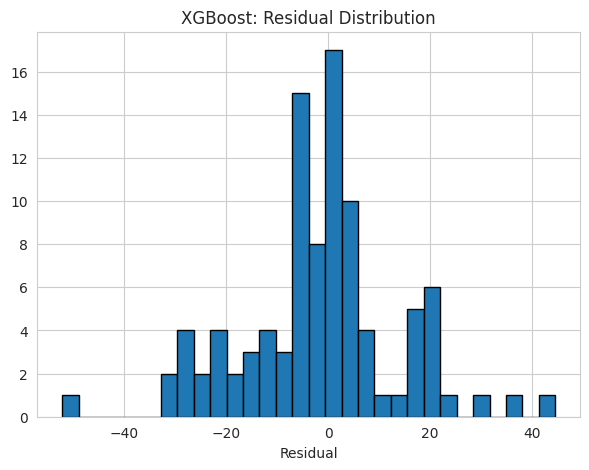

In [272]:
# --- 3. Residual Distribution ---
plt.figure(figsize=(7,5))
plt.hist(residuals_xgb, bins=30, edgecolor='black')
plt.xlabel("Residual")
plt.title("XGBoost: Residual Distribution")
plt.show()

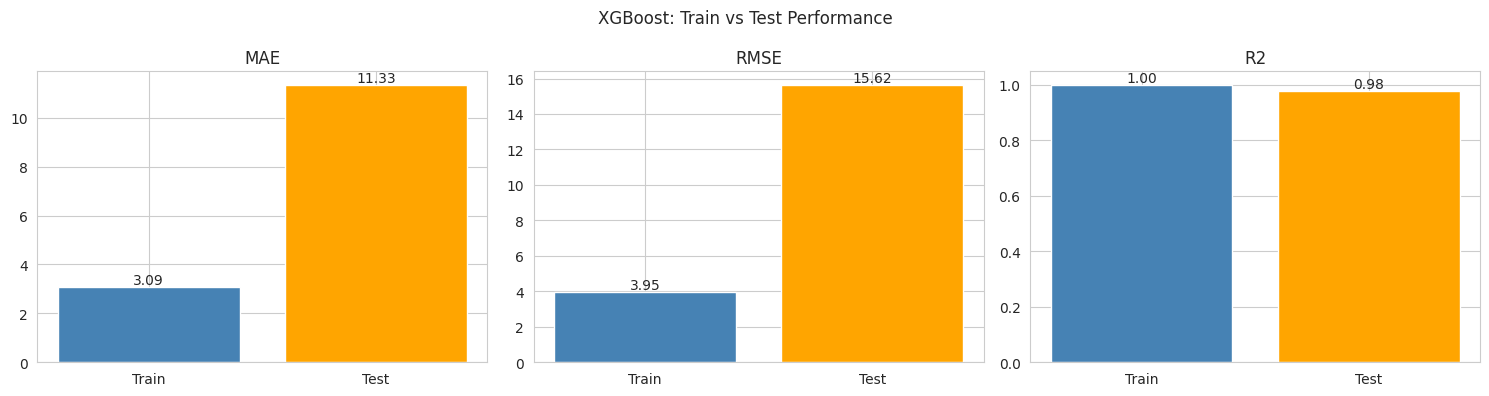

In [273]:
# --- 4. Train vs Test performance bars ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred_xgb = xgb_pipe.predict(X_train)

metrics_xgb = {
    "MAE": [mean_absolute_error(y_train, y_train_pred_xgb), mean_absolute_error(y_test, y_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)), np.sqrt(mean_squared_error(y_test, y_pred_xgb))],
    "R2": [r2_score(y_train, y_train_pred_xgb), r2_score(y_test, y_pred_xgb)]
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
labels = ["Train", "Test"]
for ax, (name, vals) in zip(axes, metrics_xgb.items()):
    ax.bar(labels, vals, color=["steelblue", "orange"])
    ax.set_title(name)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.suptitle("XGBoost: Train vs Test Performance")
plt.tight_layout()
plt.show()

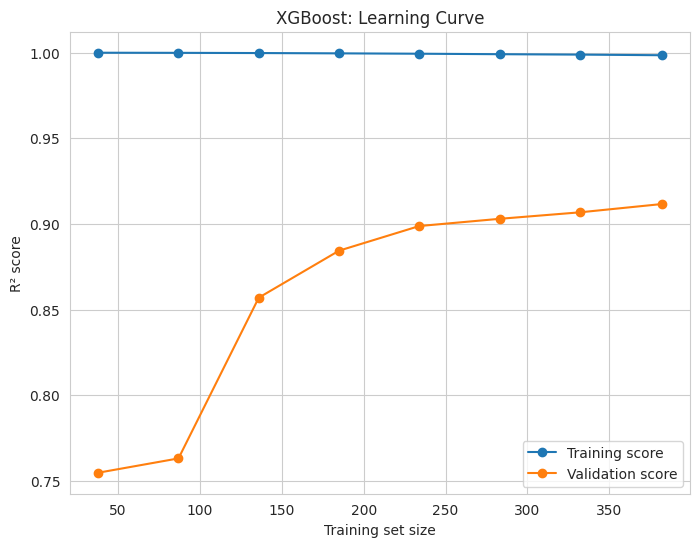

In [274]:
# --- 5. Learning Curve ---
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb_pipe, X, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("R² score")
plt.title("XGBoost: Learning Curve")
plt.legend()
plt.show()

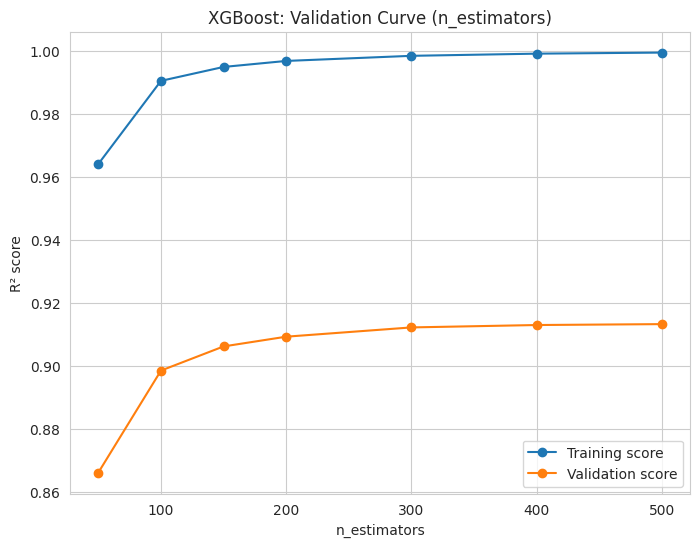

In [275]:
# --- 6. Validation Curve (n_estimators tuning) ---
from sklearn.model_selection import validation_curve

param_range = [50, 100, 150, 200, 300, 400, 500]

train_scores_vc, val_scores_vc = validation_curve(
    xgb_pipe, X, y,
    param_name="xgb__n_estimators", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_scores_vc.mean(axis=1), 'o-', label="Training score")
plt.plot(param_range, val_scores_vc.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("n_estimators")
plt.ylabel("R² score")
plt.title("XGBoost: Validation Curve (n_estimators)")
plt.legend()
plt.show()

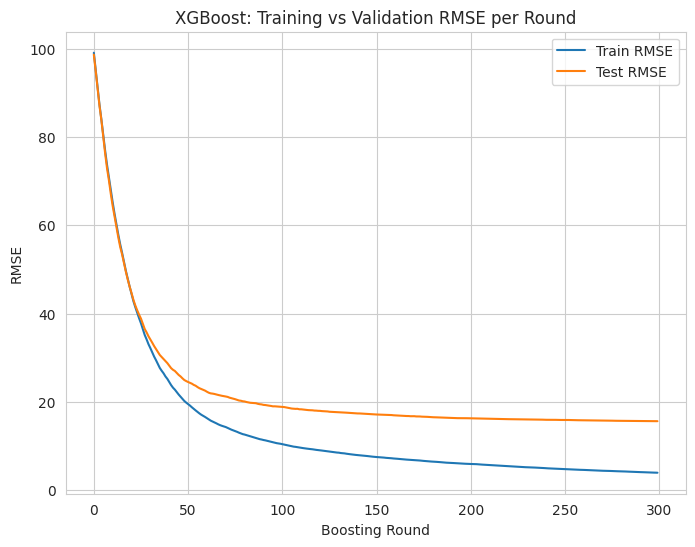

In [276]:
# --- 7. Training vs Validation Loss (native XGBoost eval, via eval_set) ---
from xgboost import XGBRegressor

# Refit a standalone XGBRegressor with eval_set to track loss curves
xgb_raw = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric="rmse"
)

X_train_prep = xgb_pipe.named_steps["prep"].transform(X_train)
X_test_prep = xgb_pipe.named_steps["prep"].transform(X_test)

xgb_raw.fit(
    X_train_prep, y_train,
    eval_set=[(X_train_prep, y_train), (X_test_prep, y_test)],
    verbose=False
)

results = xgb_raw.evals_result()
epochs = len(results["validation_0"]["rmse"])

plt.figure(figsize=(8,6))
plt.plot(range(epochs), results["validation_0"]["rmse"], label="Train RMSE")
plt.plot(range(epochs), results["validation_1"]["rmse"], label="Test RMSE")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost: Training vs Validation RMSE per Round")
plt.legend()
plt.show()

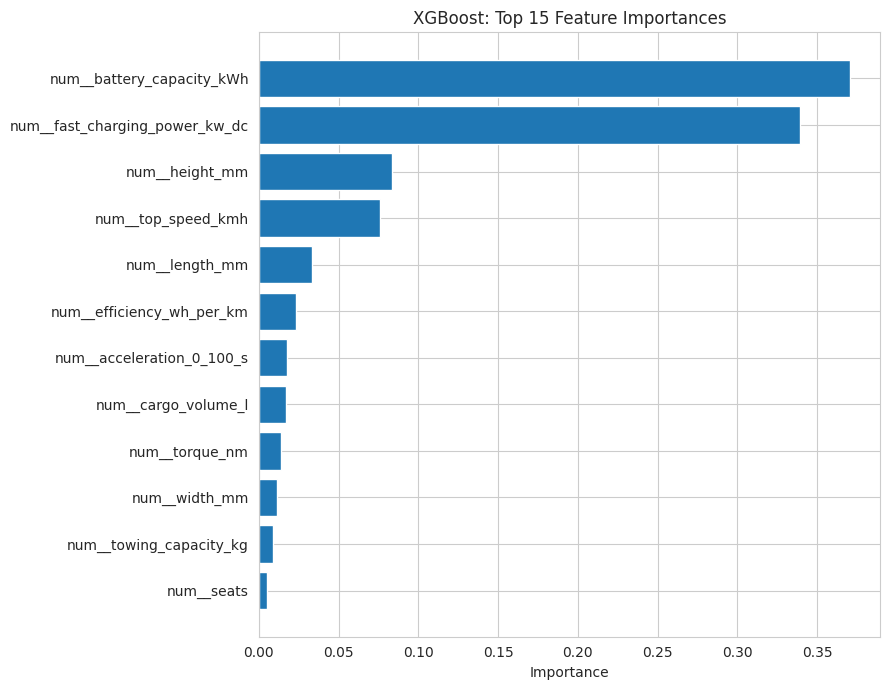

In [277]:
# --- 8. Feature Importance ---
feature_names = xgb_pipe.named_steps["prep"].get_feature_names_out()
importances_xgb = xgb_pipe.named_steps["xgb"].feature_importances_

order = np.argsort(importances_xgb)[::-1][:15]
plt.figure(figsize=(9,7))
plt.barh(np.array(feature_names)[order][::-1], importances_xgb[order][::-1])
plt.xlabel("Importance")
plt.title("XGBoost: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [278]:
# --- Save XGBoost pipeline ---
import joblib

joblib.dump(xgb_pipe, "xgboost_range_model.pkl")
print("Model saved as xgboost_range_model.pkl")

Model saved as xgboost_range_model.pkl


# LightGBM

In [279]:
!pip install lightgbm -q

In [280]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("lgb", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

lgb_pipe.fit(X_train, y_train)
y_pred_lgb = lgb_pipe.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgb)))
print("R²:", r2_score(y_test, y_pred_lgb))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 382, number of used features: 12
[LightGBM] [Info] Start training from score 393.376963
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


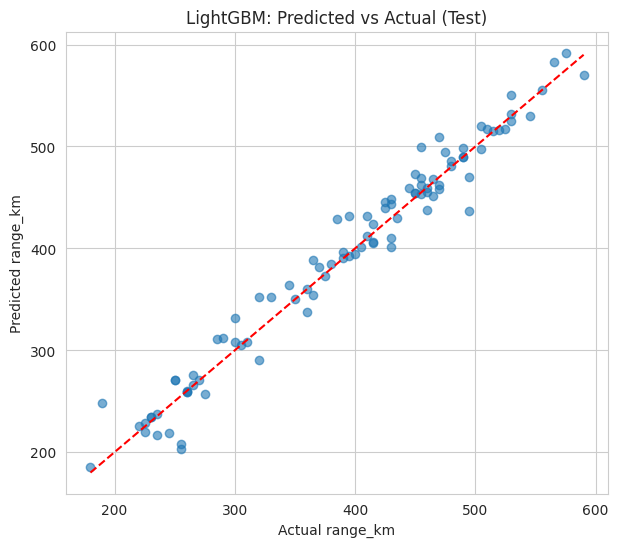

In [281]:
# --- 1. Predicted vs Actual (Test set) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_lgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual range_km")
plt.ylabel("Predicted range_km")
plt.title("LightGBM: Predicted vs Actual (Test)")
plt.show()

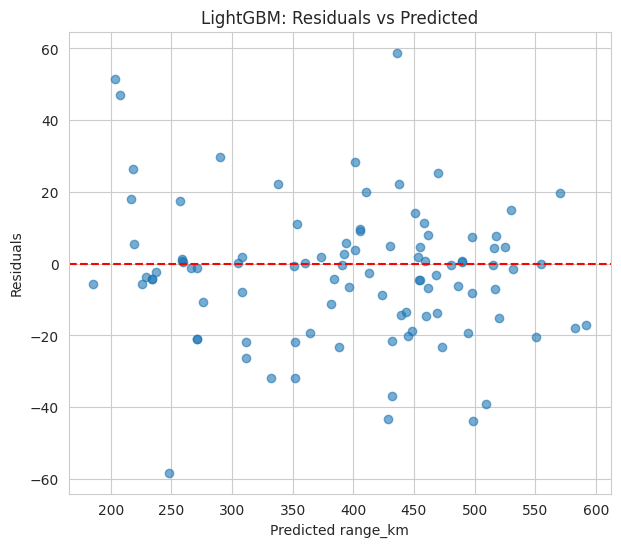

In [282]:
# --- 2. Residuals vs Predicted ---
residuals_lgb = y_test - y_pred_lgb

plt.figure(figsize=(7,6))
plt.scatter(y_pred_lgb, residuals_lgb, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted range_km")
plt.ylabel("Residuals")
plt.title("LightGBM: Residuals vs Predicted")
plt.show()

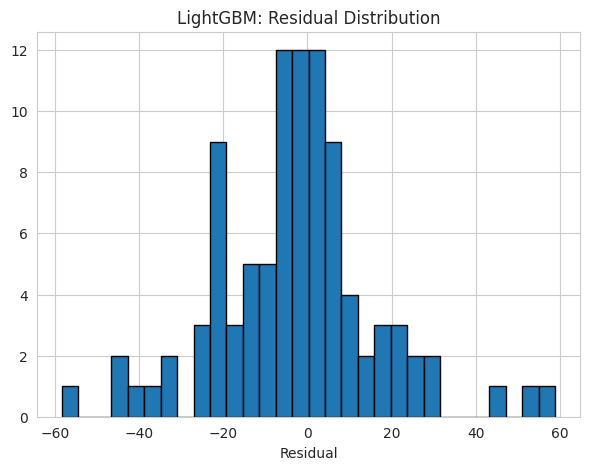

In [283]:
# --- 3. Residual Distribution ---
plt.figure(figsize=(7,5))
plt.hist(residuals_lgb, bins=30, edgecolor='black')
plt.xlabel("Residual")
plt.title("LightGBM: Residual Distribution")
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


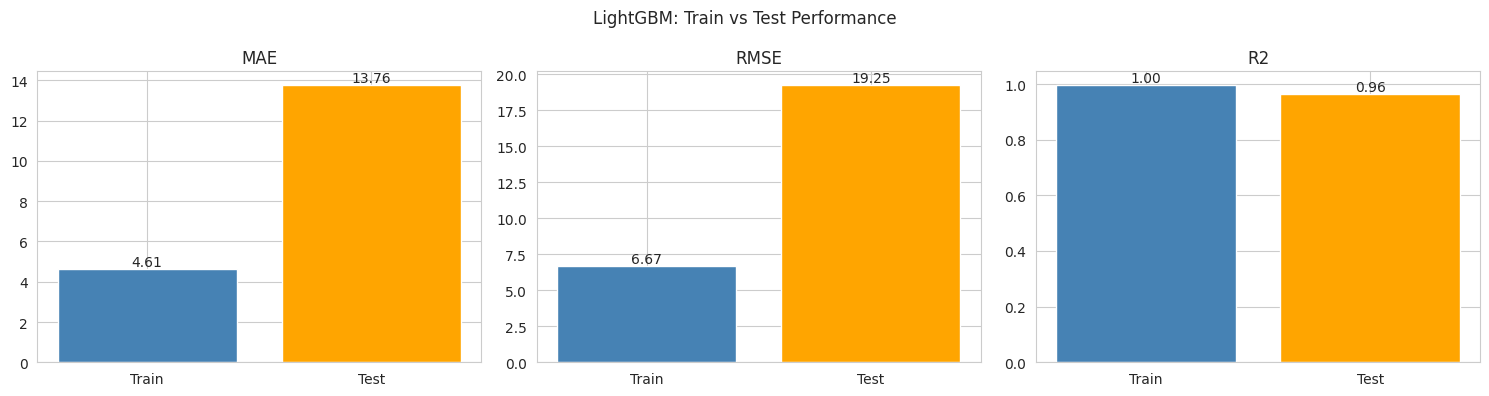

In [284]:
# --- 4. Train vs Test performance bars ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred_lgb = lgb_pipe.predict(X_train)

metrics_lgb = {
    "MAE": [mean_absolute_error(y_train, y_train_pred_lgb), mean_absolute_error(y_test, y_pred_lgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred_lgb)), np.sqrt(mean_squared_error(y_test, y_pred_lgb))],
    "R2": [r2_score(y_train, y_train_pred_lgb), r2_score(y_test, y_pred_lgb)]
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))
labels = ["Train", "Test"]
for ax, (name, vals) in zip(axes, metrics_lgb.items()):
    ax.bar(labels, vals, color=["steelblue", "orange"])
    ax.set_title(name)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')
plt.suptitle("LightGBM: Train vs Test Performance")
plt.tight_layout()
plt.show()

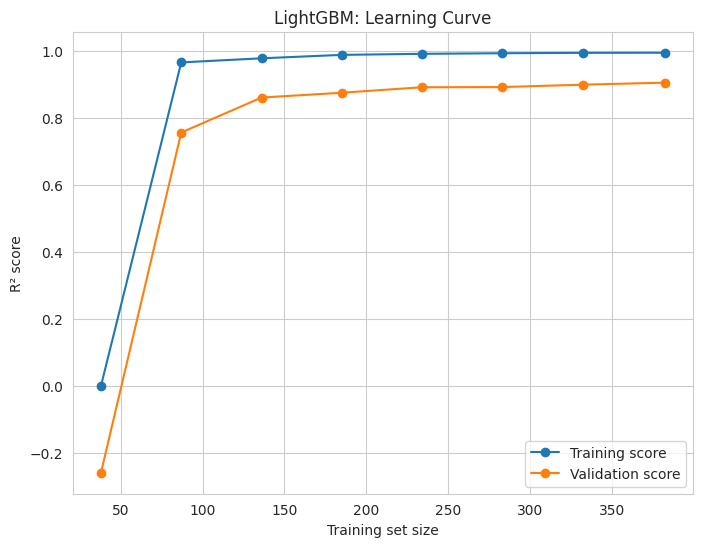

In [285]:
# --- 5. Learning Curve ---
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lgb_pipe, X, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("R² score")
plt.title("LightGBM: Learning Curve")
plt.legend()
plt.show()

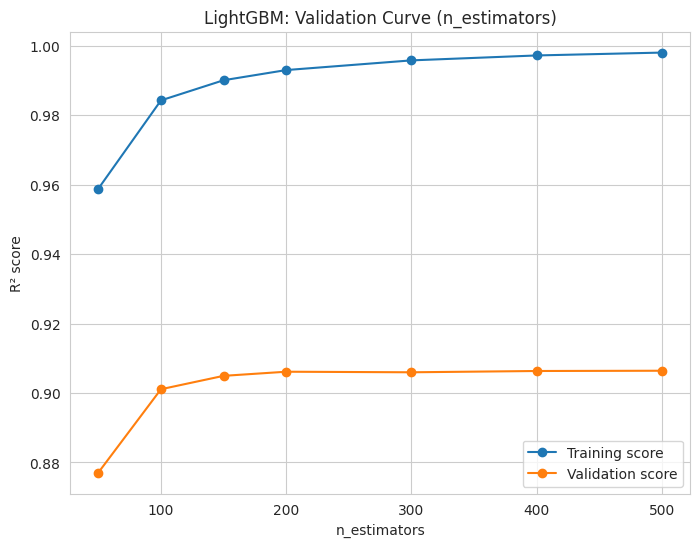

In [286]:
# --- 6. Validation Curve (n_estimators tuning) ---
from sklearn.model_selection import validation_curve

param_range = [50, 100, 150, 200, 300, 400, 500]

train_scores_vc, val_scores_vc = validation_curve(
    lgb_pipe, X, y,
    param_name="lgb__n_estimators", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_scores_vc.mean(axis=1), 'o-', label="Training score")
plt.plot(param_range, val_scores_vc.mean(axis=1), 'o-', label="Validation score")
plt.xlabel("n_estimators")
plt.ylabel("R² score")
plt.title("LightGBM: Validation Curve (n_estimators)")
plt.legend()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 717
[LightGBM] [Info] Number of data points in the train set: 382, number of used features: 12
[LightGBM] [Info] Start training from score 393.376963
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

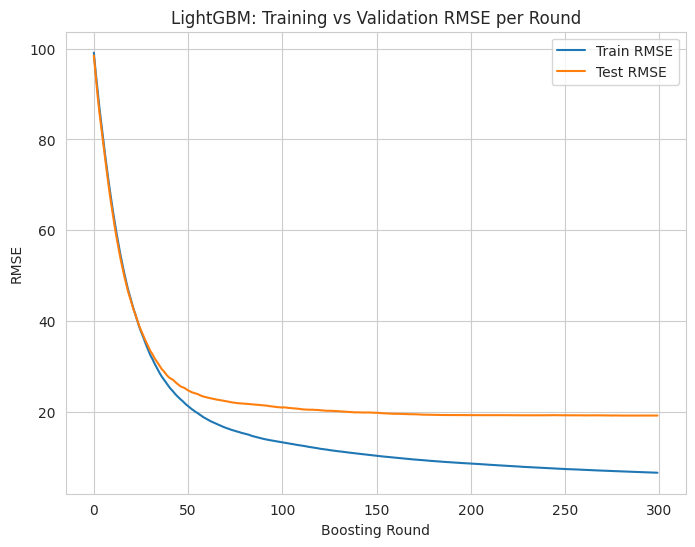

In [287]:
# --- 7. Training vs Validation Loss (native eval_set tracking) ---
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

lgb_raw = LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)

X_train_prep = lgb_pipe.named_steps["prep"].transform(X_train)
X_test_prep = lgb_pipe.named_steps["prep"].transform(X_test)

lgb_raw.fit(
    X_train_prep, y_train,
    eval_set=[(X_train_prep, y_train), (X_test_prep, y_test)],
    eval_names=["train", "test"],
    eval_metric="rmse",
    callbacks=[log_evaluation(0)]
)

results = lgb_raw.evals_result_

plt.figure(figsize=(8,6))
plt.plot(results["train"]["rmse"], label="Train RMSE")
plt.plot(results["test"]["rmse"], label="Test RMSE")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("LightGBM: Training vs Validation RMSE per Round")
plt.legend()
plt.show()

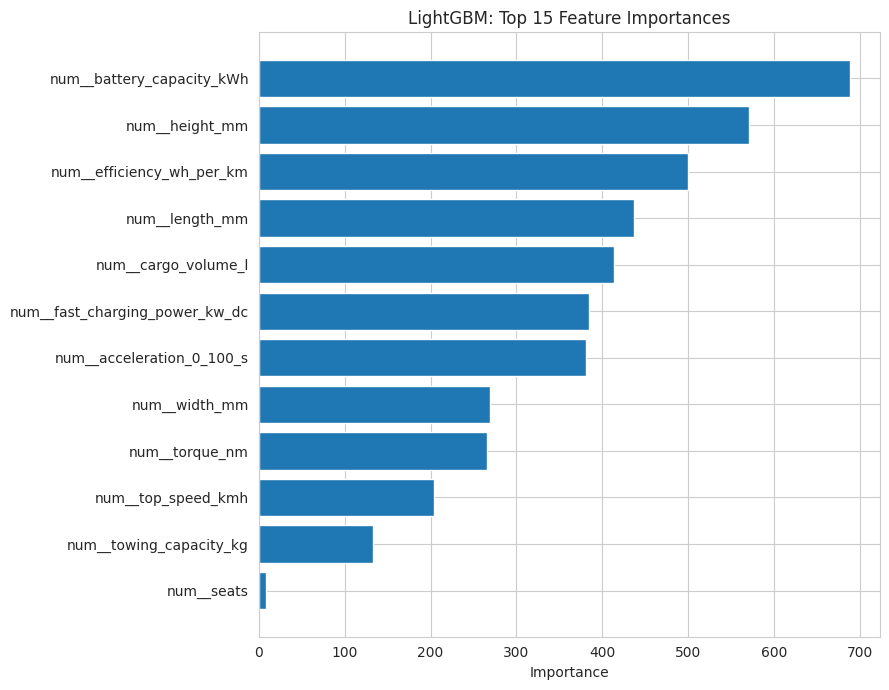

In [288]:
# --- 8. Feature Importance ---
feature_names = lgb_pipe.named_steps["prep"].get_feature_names_out()
importances_lgb = lgb_pipe.named_steps["lgb"].feature_importances_

order = np.argsort(importances_lgb)[::-1][:15]
plt.figure(figsize=(9,7))
plt.barh(np.array(feature_names)[order][::-1], importances_lgb[order][::-1])
plt.xlabel("Importance")
plt.title("LightGBM: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [289]:
# --- Save LightGBM pipeline ---
import joblib

joblib.dump(lgb_pipe, "lightgbm_range_model.pkl")
print("Model saved as lightgbm_range_model.pkl")

Model saved as lightgbm_range_model.pkl


In [292]:
import joblib

cluster_avg_range = df.groupby("cluster")["range_km"].mean().to_dict()
joblib.dump(cluster_avg_range, "cluster_avg_range.pkl")

from google.colab import files
files.download("cluster_avg_range.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [293]:
import joblib

cluster_avg_range = df.groupby("cluster")["range_km"].mean().to_dict()
joblib.dump(cluster_avg_range, "cluster_avg_range.pkl")

from google.colab import files
files.download("cluster_avg_range.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [294]:
print(list(X.columns))

['top_speed_kmh', 'battery_capacity_kWh', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm']
